In [15]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import time
## Visualization
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
# Import thêm thư viện cho Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler


# Ví dụ 1

In [16]:
np.random.seed(2)
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 30
X0 = np.random.multivariate_normal(means[0], cov, N).T
X1 = np.random.multivariate_normal(means[1], cov, N).T

X = np.concatenate((X0, X1), axis = 1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)
# Xbar
X = np.concatenate((np.ones((1, 2*N)), X), axis = 0)

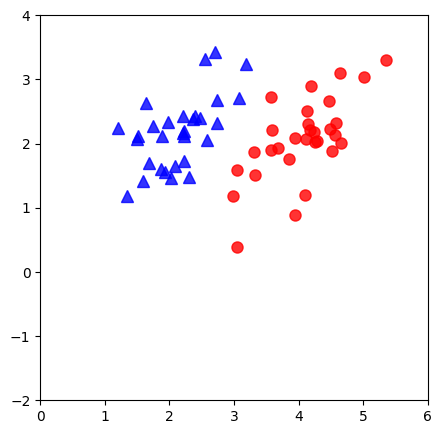

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
ani = plt.cla()
#plot points
ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize = 8, alpha = .8)
ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize = 8, alpha = .8)
ani = plt.axis([0 , 6, -2, 4])
plt.show()

In [18]:
# Define h_w(x):= W^T.x + w_0 = \bar{W}^T . \bar{x}
def h(w, x):
    return np.sign(np.dot(w.T, x))

#Stop condition
def has_converged(X, y, w):
    return np.array_equal(h(w, X), y) #True if h(w, X) == y else False

def perceptron(X, y, w_init):
    w = [w_init]
    N = X.shape[1]
    mis_points = [] # set of miss position points
    while True:
        # mix data
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(3, 1)
            yi = y[0, mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi*xi
                w.append(w_new)
        if has_converged(X, y, w[-1]):
            break
    return (w, mis_points)

In [19]:
d = X.shape[0]
w_init = np.random.randn(d, 1)
(w, m) = perceptron(X, y, w_init)
print(w[-1])

[[ 13.97858527]
 [-15.02901929]
 [ 14.38743059]]


In [20]:
def draw_line(w):
    w0, w1, w2 = w[0], w[1], w[2]
    if w2 != 0:
        x11, x12 = -100, 100
        return plt.plot([x11, x12], [-(w1*x11 + w0)/w2, -(w1*x12 + w0)/w2], 'k')
    else:
        x10 = -w0/w1
    return plt.plot([x10, x10], [-100, 100], 'k')

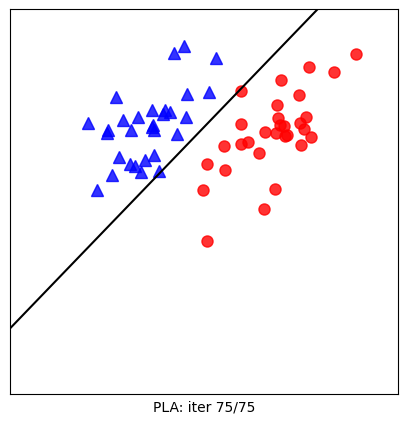

In [21]:
def viz_alg_1d_2(w):
    it = len(w)
    fig, ax = plt.subplots(figsize=(5, 5))
    def update(i):
        ani = plt.cla()
        #points
        ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize = 8, alpha = .8)
        ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize = 8, alpha = .8)
        ani = plt.axis([0 , 6, -2, 4])
        i2 = i if i < it else it-1
        ani = draw_line(w[i2])
        if i < it-1:
# draw one misclassified point
            circle = plt.Circle((X[1, m[i]], X[2, m[i]]), 0.15, color='k', fill = False)
            ax.add_artist(circle)
        # hide axis
        cur_axes = plt.gca()
        cur_axes.axes.get_xaxis().set_ticks([])
        cur_axes.axes.get_yaxis().set_ticks([])
        label = 'PLA: iter %d/%d' %(i2, it-1)
        ax.set_xlabel(label)
        return ani, ax
    anim = FuncAnimation(fig, update, frames=np.arange(0, it + 2), interval=1000)
# save
    anim.save('D:\\Workspace\\HUS\\Machine Learning\\7. Perceptron\\pla_vis.gif', dpi = 100, writer = 'imagemagick')
    plt.show()
viz_alg_1d_2(w)

# Ví dụ 2

<Axes: ylabel='60'>

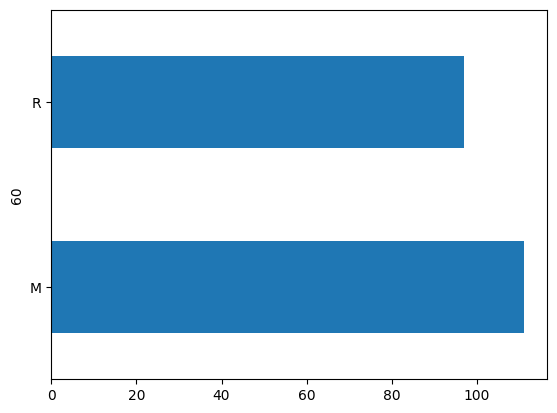

In [22]:
main_df = pd.read_csv('D:/Workspace/HUS/Machine Learning/7. Perceptron/sonar.all-data.csv',header=None)

main_df.head()

main_df[60].value_counts().plot(kind='barh')

In [23]:
y_df = main_df[60]
targes_label = {'M': 1,'R': -1}
targes_df = [targes_label[item] for item in y_df]
print(targes_df)

[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [24]:
inputs_df = main_df.drop(60, axis=1)
x0 = np.ones(( inputs_df.shape[0], 1))
X = np.concatenate((x0, inputs_df), axis = 1)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, targes_df, test_size=0.30,
random_state=42)

## a.

In [26]:
# Sử dụng các hàm từ Ví dụ 1 để huấn luyện mô hình
# Tạo phiên bản tổng quát của hàm perceptron (không hardcode reshape)
def perceptron_general(X, y, w_init, max_iter=1000, verbose=True):
    """
    Perceptron algorithm with max iterations limit
    
    Parameters:
    - X: features matrix (d, N) - d features, N samples
    - y: labels (1, N)
    - w_init: initial weights (d, 1)
    - max_iter: maximum iterations (default 1000)
    - verbose: print progress (default True)
    
    Returns:
    - w: list of weight updates
    - mis_points: list of misclassified point indices
    """
    w = [w_init]
    N = X.shape[1]
    d = X.shape[0]  # Số chiều của dữ liệu
    mis_points = [] # set of miss position points
    iteration = 0
    
    while iteration < max_iter:
        iteration += 1
        has_mistake = False
        
        # mix data
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(d, 1)  # Sử dụng d thay vì hardcode 3
            yi = y[0, mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi*xi
                w.append(w_new)
                has_mistake = True
        
        # Print progress every 50 iterations
        if verbose and iteration % 50 == 0:
            accuracy = np.sum(h(w[-1], X) == y) / N
            print(f"Iteration {iteration}/{max_iter}: Accuracy = {accuracy:.4f} ({accuracy*100:.2f}%)")
        
        # Check convergence
        if has_converged(X, y, w[-1]):
            if verbose:
                print(f"✓ Converged after {iteration} iterations!")
            break
    
    if iteration >= max_iter and not has_converged(X, y, w[-1]):
        accuracy = np.sum(h(w[-1], X) == y) / N
        if verbose:
            print(f"⚠ Reached max iterations ({max_iter}). Final accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    return (w, mis_points)

# Chuyển đổi dữ liệu về định dạng phù hợp
X_train_array = np.array(X_train).T  # Chuyển thành ma trận có kích thước (features, samples)
y_train_array = np.array(y_train).reshape(1, -1)  # Chuyển thành ma trận có kích thước (1, samples)

# Khởi tạo trọng số ngẫu nhiên
d = X_train_array.shape[0]
w_init = np.random.randn(d, 1)

# Huấn luyện mô hình Perceptron
print("="*70)
print(f"Training Perceptron with {d} features on {X_train_array.shape[1]} samples...")
print("="*70)
(w_trained, mis_points) = perceptron_general(X_train_array, y_train_array, w_init, max_iter=1000)

# In kết quả
print("\n" + "="*70)
print("TRAINING RESULTS")
print("="*70)
print(f"Number of weight updates: {len(w_trained) - 1}")
print(f"Number of misclassified points during training: {len(mis_points)}")
print(f"Final weights shape: {w_trained[-1].shape}")


Training Perceptron with 61 features on 145 samples...
Iteration 50/1000: Accuracy = 0.8069 (80.69%)
Iteration 100/1000: Accuracy = 0.8552 (85.52%)
Iteration 150/1000: Accuracy = 0.8897 (88.97%)
Iteration 200/1000: Accuracy = 0.8621 (86.21%)
Iteration 250/1000: Accuracy = 0.6759 (67.59%)
Iteration 300/1000: Accuracy = 0.8621 (86.21%)
Iteration 300/1000: Accuracy = 0.8621 (86.21%)
Iteration 350/1000: Accuracy = 0.8138 (81.38%)
Iteration 400/1000: Accuracy = 0.7931 (79.31%)
Iteration 450/1000: Accuracy = 0.7586 (75.86%)
Iteration 500/1000: Accuracy = 0.9103 (91.03%)
Iteration 550/1000: Accuracy = 0.7517 (75.17%)
Iteration 600/1000: Accuracy = 0.9172 (91.72%)
Iteration 350/1000: Accuracy = 0.8138 (81.38%)
Iteration 400/1000: Accuracy = 0.7931 (79.31%)
Iteration 450/1000: Accuracy = 0.7586 (75.86%)
Iteration 500/1000: Accuracy = 0.9103 (91.03%)
Iteration 550/1000: Accuracy = 0.7517 (75.17%)
Iteration 600/1000: Accuracy = 0.9172 (91.72%)
Iteration 650/1000: Accuracy = 0.9103 (91.03%)
Iterat

## b.

===== KẾT QUẢ TEST TRÊN TẬP DỮ LIỆU TEST =====

Tỷ lệ train:test = 7:3
Số mẫu train: 145
Số mẫu test: 63


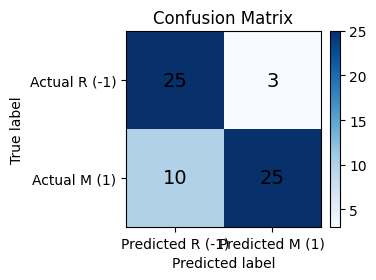


Các độ đo đánh giá:
  Accuracy:  0.7937 (79.37%)
  Precision: 0.8929 (89.29%)
  Recall:    0.7143 (71.43%)


In [27]:
# Test mô hình với tập dữ liệu test
# Chuyển đổi dữ liệu test về định dạng phù hợp
X_test_array = np.array(X_test).T  # Chuyển thành ma trận có kích thước (features, samples)
y_test_array = np.array(y_test).reshape(1, -1)  # Chuyển thành ma trận có kích thước (1, samples)

# Dự đoán trên tập test
y_pred = h(w_trained[-1], X_test_array)

# Tính các độ đo
# True Positive (TP): dự đoán 1, thực tế 1
# True Negative (TN): dự đoán -1, thực tế -1
# False Positive (FP): dự đoán 1, thực tế -1
# False Negative (FN): dự đoán -1, thực tế 1

TP = np.sum((y_pred == 1) & (y_test_array == 1))
TN = np.sum((y_pred == -1) & (y_test_array == -1))
FP = np.sum((y_pred == 1) & (y_test_array == -1))
FN = np.sum((y_pred == -1) & (y_test_array == 1))

# Accuracy: (TP + TN) / (TP + TN + FP + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Precision: TP / (TP + FP)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Recall: TP / (TP + FN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

# In kết quả
print("===== KẾT QUẢ TEST TRÊN TẬP DỮ LIỆU TEST =====")
print(f"\nTỷ lệ train:test = 7:3")
print(f"Số mẫu train: {X_train_array.shape[1]}")
print(f"Số mẫu test: {X_test_array.shape[1]}")
# Vẽ confusion matrix bằng matplotlib
cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Ghi số vào ô
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black', fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted R (-1)', 'Predicted M (1)'])
ax.set_yticklabels(['Actual R (-1)', 'Actual M (1)'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()
print(f"\nCác độ đo đánh giá:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")

## c.

In [28]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Hàm tính các độ đo
def calculate_metrics(y_true, y_pred):
    """Tính accuracy, precision, recall và confusion matrix"""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == -1) & (y_true == -1))
    FP = np.sum((y_pred == 1) & (y_true == -1))
    FN = np.sum((y_pred == -1) & (y_true == 1))
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    return accuracy, precision, recall, TP, TN, FP, FN

# Dictionary để lưu kết quả
results = {}

print("="*70)
print("SO SÁNH CÁC PHƯƠNG PHÁP PHÂN LOẠI")
print("="*70)

# 1. PERCEPTRON (đã train ở trên)
print("\n1. PERCEPTRON")
print("-"*70)
start_time = time.time()
# Train
X_train_array = np.array(X_train).T
y_train_array = np.array(y_train).reshape(1, -1)
d = X_train_array.shape[0]
w_init = np.random.randn(d, 1)
(w_trained, mis_points) = perceptron_general(X_train_array, y_train_array, w_init)
# Test
X_test_array = np.array(X_test).T
y_test_array = np.array(y_test).reshape(1, -1)
y_pred_perceptron = h(w_trained[-1], X_test_array)
perceptron_time = time.time() - start_time

acc, prec, rec, tp, tn, fp, fn = calculate_metrics(y_test_array, y_pred_perceptron)
results['Perceptron'] = {
    'time': perceptron_time,
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

print(f"Thời gian train + test: {perceptron_time:.4f} giây")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.2f}%)")
print(f"Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

# 2. LOGISTIC REGRESSION
print("\n2. LOGISTIC REGRESSION")
print("-"*70)
start_time = time.time()
# Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
# Test
y_pred_lr = lr_model.predict(X_test)
lr_time = time.time() - start_time

acc, prec, rec, tp, tn, fp, fn = calculate_metrics(y_test, y_pred_lr)
results['Logistic Regression'] = {
    'time': lr_time,
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

print(f"Thời gian train + test: {lr_time:.4f} giây")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.2f}%)")
print(f"Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

# 3. NAIVE BAYES
print("\n3. NAIVE BAYES (Gaussian)")
print("-"*70)
start_time = time.time()
# Train
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
# Test
y_pred_nb = nb_model.predict(X_test)
nb_time = time.time() - start_time

acc, prec, rec, tp, tn, fp, fn = calculate_metrics(y_test, y_pred_nb)
results['Naive Bayes'] = {
    'time': nb_time,
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

print(f"Thời gian train + test: {nb_time:.4f} giây")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.2f}%)")
print(f"Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

SO SÁNH CÁC PHƯƠNG PHÁP PHÂN LOẠI

1. PERCEPTRON
----------------------------------------------------------------------
Iteration 50/1000: Accuracy = 0.7655 (76.55%)
Iteration 100/1000: Accuracy = 0.8483 (84.83%)
Iteration 150/1000: Accuracy = 0.7034 (70.34%)
Iteration 150/1000: Accuracy = 0.7034 (70.34%)
Iteration 200/1000: Accuracy = 0.8552 (85.52%)
Iteration 250/1000: Accuracy = 0.8414 (84.14%)
Iteration 200/1000: Accuracy = 0.8552 (85.52%)
Iteration 250/1000: Accuracy = 0.8414 (84.14%)
Iteration 300/1000: Accuracy = 0.7655 (76.55%)
Iteration 300/1000: Accuracy = 0.7655 (76.55%)
Iteration 350/1000: Accuracy = 0.7586 (75.86%)
Iteration 400/1000: Accuracy = 0.6897 (68.97%)
Iteration 450/1000: Accuracy = 0.8966 (89.66%)
Iteration 350/1000: Accuracy = 0.7586 (75.86%)
Iteration 400/1000: Accuracy = 0.6897 (68.97%)
Iteration 450/1000: Accuracy = 0.8966 (89.66%)
Iteration 500/1000: Accuracy = 0.9034 (90.34%)
Iteration 500/1000: Accuracy = 0.9034 (90.34%)
Iteration 550/1000: Accuracy = 0.87

In [29]:
# Tạo bảng so sánh
print("\n" + "="*70)
print("BẢNG SO SÁNH KẾT QUẢ")
print("="*70)

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['time', 'accuracy', 'precision', 'recall']]
comparison_df.columns = ['Thời gian (s)', 'Accuracy', 'Precision', 'Recall']

print("\n", comparison_df.to_string())

# Tìm phương pháp tốt nhất cho từng tiêu chí
print("\n" + "="*70)
print("PHƯƠNG PHÁP TỐT NHẤT CHO TỪNG TIÊU CHÍ")
print("="*70)
print(f"Nhanh nhất:        {comparison_df['Thời gian (s)'].idxmin()} ({comparison_df['Thời gian (s)'].min():.4f}s)")
print(f"Accuracy cao nhất: {comparison_df['Accuracy'].idxmax()} ({comparison_df['Accuracy'].max():.4f})")
print(f"Precision cao nhất: {comparison_df['Precision'].idxmax()} ({comparison_df['Precision'].max():.4f})")
print(f"Recall cao nhất:   {comparison_df['Recall'].idxmax()} ({comparison_df['Recall'].max():.4f})")


BẢNG SO SÁNH KẾT QUẢ

                      Thời gian (s)  Accuracy  Precision    Recall
Perceptron                0.643811  0.746032   0.756757  0.800000
Logistic Regression       0.006269  0.809524   0.810811  0.857143
Naive Bayes               0.001008  0.777778   0.920000  0.657143

PHƯƠNG PHÁP TỐT NHẤT CHO TỪNG TIÊU CHÍ
Nhanh nhất:        Naive Bayes (0.0010s)
Accuracy cao nhất: Logistic Regression (0.8095)
Precision cao nhất: Naive Bayes (0.9200)
Recall cao nhất:   Logistic Regression (0.8571)


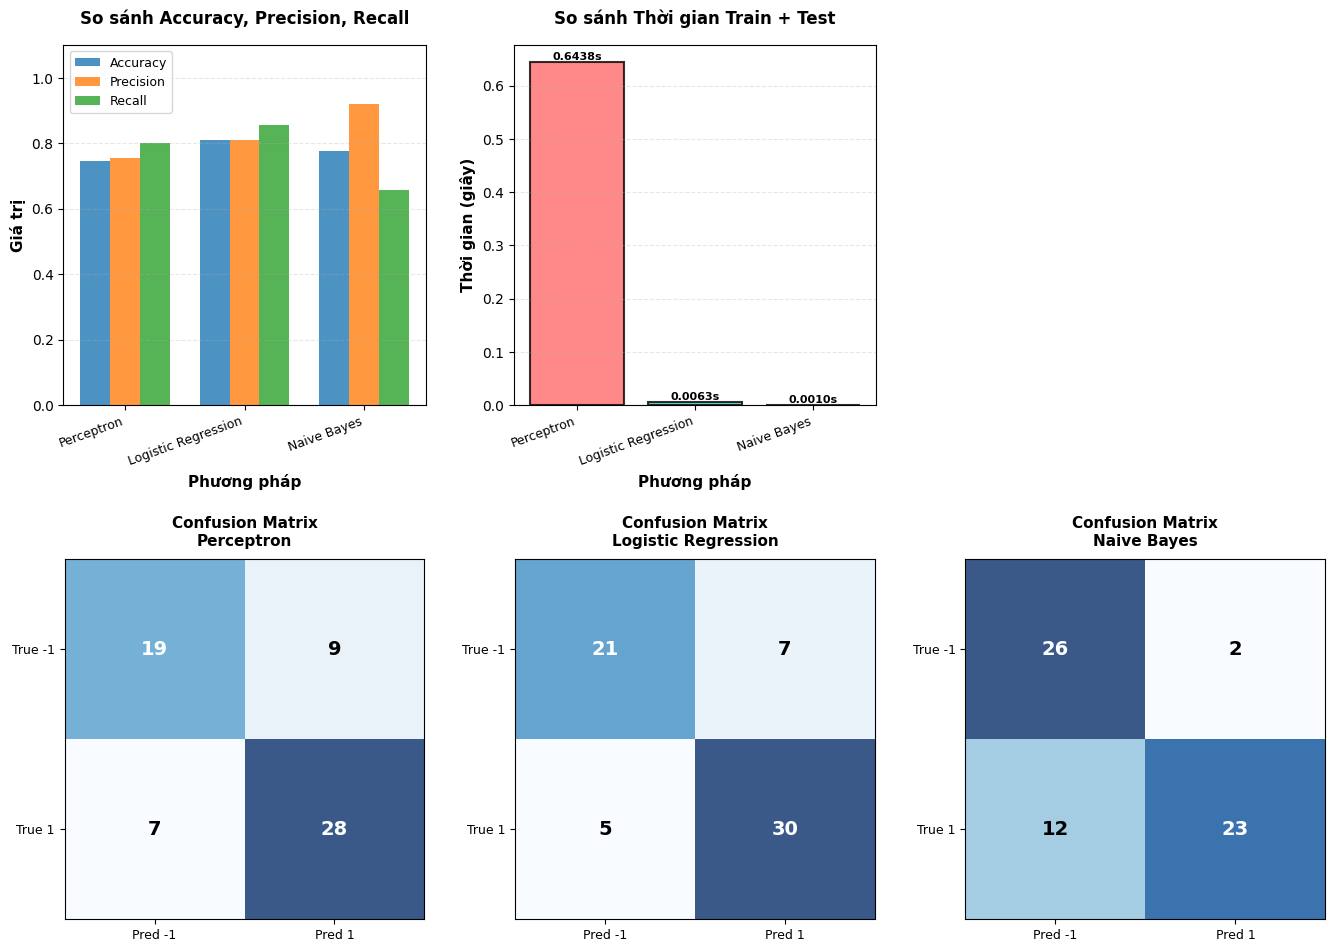

In [30]:
# Vẽ biểu đồ so sánh với layout tốt hơn
fig = plt.figure(figsize=(14, 10))

methods = list(results.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# 1. So sánh Accuracy, Precision, Recall
ax1 = plt.subplot(2, 3, 1)
metrics = ['accuracy', 'precision', 'recall']
metric_labels = ['Accuracy', 'Precision', 'Recall']
x = np.arange(len(methods))
width = 0.25

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in methods]
    ax1.bar(x + i*width, values, width, label=metric_labels[i], alpha=0.8)

ax1.set_xlabel('Phương pháp', fontsize=11, fontweight='bold')
ax1.set_ylabel('Giá trị', fontsize=11, fontweight='bold')
ax1.set_title('So sánh Accuracy, Precision, Recall', fontsize=12, fontweight='bold', pad=15)
ax1.set_xticks(x + width)
ax1.set_xticklabels(methods, rotation=20, ha='right', fontsize=9)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0, 1.1])

# 2. So sánh thời gian chạy
ax2 = plt.subplot(2, 3, 2)
times = [results[m]['time'] for m in methods]
bars = ax2.bar(methods, times, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Phương pháp', fontsize=11, fontweight='bold')
ax2.set_ylabel('Thời gian (giây)', fontsize=11, fontweight='bold')
ax2.set_title('So sánh Thời gian Train + Test', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, rotation=20, ha='right', fontsize=9)
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.4f}s', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Confusion Matrix cho từng phương pháp
for idx, method in enumerate(methods):
    ax = plt.subplot(2, 3, 4 + idx)
    
    cm = np.array([[results[method]['TN'], results[method]['FP']],
                   [results[method]['FN'], results[method]['TP']]])
    
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', alpha=0.8)
    
    # Ghi số vào các ô
    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', 
                   color=text_color, fontsize=14, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred -1', 'Pred 1'], fontsize=9)
    ax.set_yticklabels(['True -1', 'True 1'], fontsize=9)
    ax.set_title(f'Confusion Matrix\n{method}', fontsize=11, fontweight='bold', pad=10)

plt.tight_layout(pad=3.0, w_pad=2.5, h_pad=3.0)
plt.show()

# Ví dụ 3

In [31]:
cancer_data = datasets.load_breast_cancer()
# show to test record 5th
print(cancer_data.data[5])
print(cancer_data.data.shape)
#target set
print(cancer_data.target)

cancer_data = datasets.load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer_data.data, cancer_data.target, test_size=0.3,random_state=109)

[1.245e+01 1.570e+01 8.257e+01 4.771e+02 1.278e-01 1.700e-01 1.578e-01
 8.089e-02 2.087e-01 7.613e-02 3.345e-01 8.902e-01 2.217e+00 2.719e+01
 7.510e-03 3.345e-02 3.672e-02 1.137e-02 2.165e-02 5.082e-03 1.547e+01
 2.375e+01 1.034e+02 7.416e+02 1.791e-01 5.249e-01 5.355e-01 1.741e-01
 3.985e-01 1.244e-01]
(569, 30)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 

## a. Giảm chiều dữ liệu về 2 chiều và huấn luyện Perceptron

GIẢM CHIỀU DỮ LIỆU BẰNG PCA
Kích thước dữ liệu gốc: 30 chiều
Kích thước sau khi giảm chiều: 2 chiều
Tỷ lệ phương sai giữ lại: 0.9980 (99.80%)
Phương sai từng thành phần: [0.98058807 0.01739502]


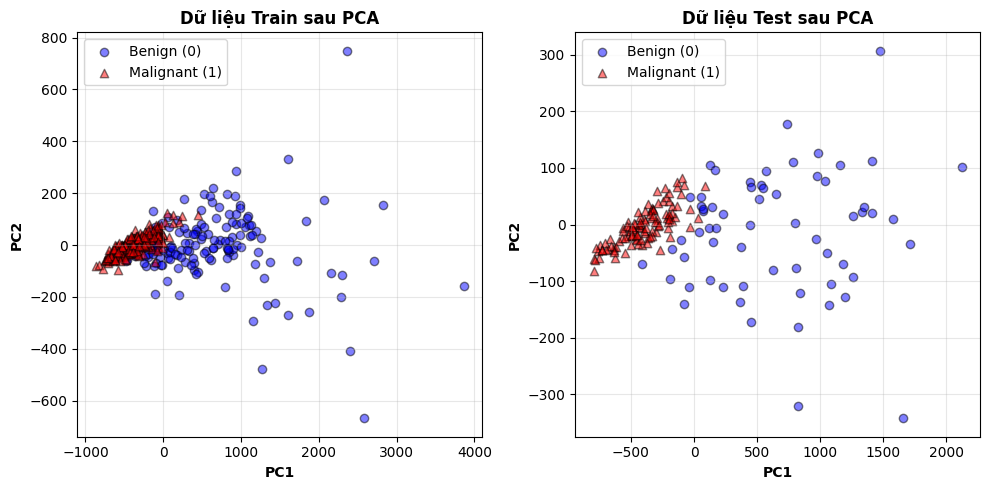


HUẤN LUYỆN PERCEPTRON VỚI DỮ LIỆU 2 CHIỀU

Đang huấn luyện Perceptron...
Iteration 50/1000: Accuracy = 0.9095 (90.95%)
Iteration 100/1000: Accuracy = 0.9070 (90.70%)
Iteration 150/1000: Accuracy = 0.9070 (90.70%)
Iteration 100/1000: Accuracy = 0.9070 (90.70%)
Iteration 150/1000: Accuracy = 0.9070 (90.70%)
Iteration 200/1000: Accuracy = 0.9121 (91.21%)
Iteration 250/1000: Accuracy = 0.8970 (89.70%)
Iteration 200/1000: Accuracy = 0.9121 (91.21%)
Iteration 250/1000: Accuracy = 0.8970 (89.70%)
Iteration 300/1000: Accuracy = 0.9095 (90.95%)
Iteration 350/1000: Accuracy = 0.9045 (90.45%)
Iteration 300/1000: Accuracy = 0.9095 (90.95%)
Iteration 350/1000: Accuracy = 0.9045 (90.45%)
Iteration 400/1000: Accuracy = 0.8920 (89.20%)
Iteration 450/1000: Accuracy = 0.9020 (90.20%)
Iteration 400/1000: Accuracy = 0.8920 (89.20%)
Iteration 450/1000: Accuracy = 0.9020 (90.20%)
Iteration 500/1000: Accuracy = 0.9095 (90.95%)
Iteration 550/1000: Accuracy = 0.9045 (90.45%)
Iteration 500/1000: Accuracy = 0.9

In [32]:
from sklearn.decomposition import PCA

# Bước 1: Giảm chiều dữ liệu về 2 chiều bằng PCA
print("="*70)
print("GIẢM CHIỀU DỮ LIỆU BẰNG PCA")
print("="*70)
print(f"Kích thước dữ liệu gốc: {X_train.shape[1]} chiều")

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Kích thước sau khi giảm chiều: {X_train_pca.shape[1]} chiều")
print(f"Tỷ lệ phương sai giữ lại: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"Phương sai từng thành phần: {pca.explained_variance_ratio_}")

# Bước 2: Visualization dữ liệu sau khi giảm chiều
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train_pca[y_train==0, 0], X_train_pca[y_train==0, 1], 
           c='blue', marker='o', alpha=0.5, label='Benign (0)', edgecolors='k')
plt.scatter(X_train_pca[y_train==1, 0], X_train_pca[y_train==1, 1], 
           c='red', marker='^', alpha=0.5, label='Malignant (1)', edgecolors='k')
plt.xlabel('PC1', fontweight='bold')
plt.ylabel('PC2', fontweight='bold')
plt.title('Dữ liệu Train sau PCA', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_test_pca[y_test==0, 0], X_test_pca[y_test==0, 1], 
           c='blue', marker='o', alpha=0.5, label='Benign (0)', edgecolors='k')
plt.scatter(X_test_pca[y_test==1, 0], X_test_pca[y_test==1, 1], 
           c='red', marker='^', alpha=0.5, label='Malignant (1)', edgecolors='k')
plt.xlabel('PC1', fontweight='bold')
plt.ylabel('PC2', fontweight='bold')
plt.title('Dữ liệu Test sau PCA', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Bước 3: Chuẩn bị dữ liệu cho Perceptron
print(f"\n{'='*70}")
print("HUẤN LUYỆN PERCEPTRON VỚI DỮ LIỆU 2 CHIỀU")
print("="*70)

# Chuyển đổi target từ {0, 1} sang {-1, 1} cho Perceptron
y_train_perceptron = np.where(y_train == 0, -1, 1)
y_test_perceptron = np.where(y_test == 0, -1, 1)

# Thêm bias term (x0 = 1)
x0_train = np.ones((X_train_pca.shape[0], 1))
X_train_with_bias = np.concatenate((x0_train, X_train_pca), axis=1)

x0_test = np.ones((X_test_pca.shape[0], 1))
X_test_with_bias = np.concatenate((x0_test, X_test_pca), axis=1)

# Chuyển đổi dữ liệu về định dạng phù hợp cho Perceptron (features, samples)
X_train_array_v3 = X_train_with_bias.T
y_train_array_v3 = y_train_perceptron.reshape(1, -1)

# Khởi tạo trọng số ngẫu nhiên
d_v3 = X_train_array_v3.shape[0]  # Bây giờ là 3 (bias + 2 features)
w_init_v3 = np.random.randn(d_v3, 1)

# Huấn luyện mô hình Perceptron
print("\nĐang huấn luyện Perceptron...")
(w_trained_v3, mis_points_v3) = perceptron_general(X_train_array_v3, y_train_array_v3, w_init_v3)

# In kết quả
print("\n" + "="*70)
print("KẾT QUẢ HUẤN LUYỆN PERCEPTRON")
print("="*70)
print(f"Số chiều dữ liệu (+ bias): {d_v3}")
print(f"Số lần lặp: {len(w_trained_v3) - 1}")
print(f"Số điểm bị phân loại sai: {len(mis_points_v3)}")
print(f"Trọng số cuối cùng: w0={w_trained_v3[-1][0][0]:.4f}, w1={w_trained_v3[-1][1][0]:.4f}, w2={w_trained_v3[-1][2][0]:.4f}")

## b. Test và đánh giá mô hình

===== KẾT QUẢ TEST TRÊN TẬP DỮ LIỆU TEST - VÍ DỤ 3 =====

Tỷ lệ train:test = 7:3
Số mẫu train: 398
Số mẫu test: 171

Confusion Matrix:
  TP (True Positive):  105
  TN (True Negative):  59
  FP (False Positive): 4
  FN (False Negative): 3

Các độ đo đánh giá:
  Accuracy:  0.9591 (95.91%)
  Precision: 0.9633 (96.33%)
  Recall:    0.9722 (97.22%)


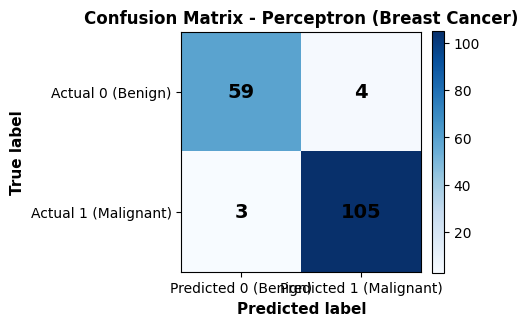

In [33]:
# Test mô hình với tập dữ liệu test
X_test_array_v3 = X_test_with_bias.T
y_test_array_v3 = y_test_perceptron.reshape(1, -1)

# Dự đoán trên tập test
y_pred_v3 = h(w_trained_v3[-1], X_test_array_v3)

# Tính các độ đo
TP_v3 = np.sum((y_pred_v3 == 1) & (y_test_array_v3 == 1))
TN_v3 = np.sum((y_pred_v3 == -1) & (y_test_array_v3 == -1))
FP_v3 = np.sum((y_pred_v3 == 1) & (y_test_array_v3 == -1))
FN_v3 = np.sum((y_pred_v3 == -1) & (y_test_array_v3 == 1))

accuracy_v3 = (TP_v3 + TN_v3) / (TP_v3 + TN_v3 + FP_v3 + FN_v3)
precision_v3 = TP_v3 / (TP_v3 + FP_v3) if (TP_v3 + FP_v3) > 0 else 0
recall_v3 = TP_v3 / (TP_v3 + FN_v3) if (TP_v3 + FN_v3) > 0 else 0

# In kết quả
print("===== KẾT QUẢ TEST TRÊN TẬP DỮ LIỆU TEST - VÍ DỤ 3 =====")
print(f"\nTỷ lệ train:test = 7:3")
print(f"Số mẫu train: {X_train_array_v3.shape[1]}")
print(f"Số mẫu test: {X_test_array_v3.shape[1]}")
print(f"\nConfusion Matrix:")
print(f"  TP (True Positive):  {TP_v3}")
print(f"  TN (True Negative):  {TN_v3}")
print(f"  FP (False Positive): {FP_v3}")
print(f"  FN (False Negative): {FN_v3}")
print(f"\nCác độ đo đánh giá:")
print(f"  Accuracy:  {accuracy_v3:.4f} ({accuracy_v3*100:.2f}%)")
print(f"  Precision: {precision_v3:.4f} ({precision_v3*100:.2f}%)")
print(f"  Recall:    {recall_v3:.4f} ({recall_v3*100:.2f}%)")

# Vẽ confusion matrix
cm_v3 = np.array([[TN_v3, FP_v3],
                  [FN_v3, TP_v3]])

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm_v3, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Ghi số vào ô
for i in range(cm_v3.shape[0]):
    for j in range(cm_v3.shape[1]):
        ax.text(j, i, int(cm_v3[i, j]), ha='center', va='center', 
                color='black', fontsize=14, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted 0 (Benign)', 'Predicted 1 (Malignant)'])
ax.set_yticklabels(['Actual 0 (Benign)', 'Actual 1 (Malignant)'])
ax.set_xlabel('Predicted label', fontsize=11, fontweight='bold')
ax.set_ylabel('True label', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix - Perceptron (Breast Cancer)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## c. So sánh với Logistic Regression và Naive Bayes

In [34]:
# Hàm tính các độ đo cho target {0, 1}
def calculate_metrics_binary(y_true, y_pred):
    """Tính accuracy, precision, recall cho binary classification {0, 1}"""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    return accuracy, precision, recall, TP, TN, FP, FN

# Dictionary để lưu kết quả
results_v3 = {}

print("="*70)
print("SO SÁNH CÁC PHƯƠNG PHÁP - VÍ DỤ 3 (BREAST CANCER)")
print("="*70)

# 1. PERCEPTRON
print("\n1. PERCEPTRON")
print("-"*70)
start_time = time.time()
# Đã train ở trên, chỉ cần test
y_pred_perceptron_v3 = h(w_trained_v3[-1], X_test_array_v3)
# Chuyển đổi về {0, 1} để so sánh
y_pred_perceptron_v3_binary = np.where(y_pred_perceptron_v3 == -1, 0, 1).flatten()
perceptron_time_v3 = time.time() - start_time

acc, prec, rec, tp, tn, fp, fn = calculate_metrics_binary(y_test, y_pred_perceptron_v3_binary)
results_v3['Perceptron'] = {
    'time': perceptron_time_v3,
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

print(f"Thời gian test: {perceptron_time_v3:.4f} giây")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.2f}%)")
print(f"Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

# 2. LOGISTIC REGRESSION
print("\n2. LOGISTIC REGRESSION")
print("-"*70)
start_time = time.time()
lr_model_v3 = LogisticRegression(max_iter=1000, random_state=42)
lr_model_v3.fit(X_train, y_train)
y_pred_lr_v3 = lr_model_v3.predict(X_test)
lr_time_v3 = time.time() - start_time

acc, prec, rec, tp, tn, fp, fn = calculate_metrics_binary(y_test, y_pred_lr_v3)
results_v3['Logistic Regression'] = {
    'time': lr_time_v3,
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

print(f"Thời gian train + test: {lr_time_v3:.4f} giây")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.2f}%)")
print(f"Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

# 3. NAIVE BAYES
print("\n3. NAIVE BAYES (Gaussian)")
print("-"*70)
start_time = time.time()
nb_model_v3 = GaussianNB()
nb_model_v3.fit(X_train, y_train)
y_pred_nb_v3 = nb_model_v3.predict(X_test)
nb_time_v3 = time.time() - start_time

acc, prec, rec, tp, tn, fp, fn = calculate_metrics_binary(y_test, y_pred_nb_v3)
results_v3['Naive Bayes'] = {
    'time': nb_time_v3,
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

print(f"Thời gian train + test: {nb_time_v3:.4f} giây")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.2f}%)")
print(f"Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

SO SÁNH CÁC PHƯƠNG PHÁP - VÍ DỤ 3 (BREAST CANCER)

1. PERCEPTRON
----------------------------------------------------------------------
Thời gian test: 0.0001 giây
Accuracy:  0.9591 (95.91%)
Precision: 0.9633 (96.33%)
Recall:    0.9722 (97.22%)
Confusion Matrix: TP=105, TN=59, FP=4, FN=3

2. LOGISTIC REGRESSION
----------------------------------------------------------------------


Thời gian train + test: 0.2831 giây
Accuracy:  0.9708 (97.08%)
Precision: 0.9813 (98.13%)
Recall:    0.9722 (97.22%)
Confusion Matrix: TP=105, TN=61, FP=2, FN=3

3. NAIVE BAYES (Gaussian)
----------------------------------------------------------------------
Thời gian train + test: 0.0019 giây
Accuracy:  0.9532 (95.32%)
Precision: 0.9464 (94.64%)
Recall:    0.9815 (98.15%)
Confusion Matrix: TP=106, TN=57, FP=6, FN=2


In [35]:
# Tạo bảng so sánh
print("\n" + "="*70)
print("BẢNG SO SÁNH KẾT QUẢ - VÍ DỤ 3")
print("="*70)

comparison_df_v3 = pd.DataFrame(results_v3).T
comparison_df_v3 = comparison_df_v3[['time', 'accuracy', 'precision', 'recall']]
comparison_df_v3.columns = ['Thời gian (s)', 'Accuracy', 'Precision', 'Recall']

print("\n", comparison_df_v3.to_string())

# Tìm phương pháp tốt nhất cho từng tiêu chí
print("\n" + "="*70)
print("PHƯƠNG PHÁP TỐT NHẤT CHO TỪNG TIÊU CHÍ")
print("="*70)
print(f"Nhanh nhất:         {comparison_df_v3['Thời gian (s)'].idxmin()} ({comparison_df_v3['Thời gian (s)'].min():.4f}s)")
print(f"Accuracy cao nhất:  {comparison_df_v3['Accuracy'].idxmax()} ({comparison_df_v3['Accuracy'].max():.4f})")
print(f"Precision cao nhất: {comparison_df_v3['Precision'].idxmax()} ({comparison_df_v3['Precision'].max():.4f})")
print(f"Recall cao nhất:    {comparison_df_v3['Recall'].idxmax()} ({comparison_df_v3['Recall'].max():.4f})")


BẢNG SO SÁNH KẾT QUẢ - VÍ DỤ 3

                      Thời gian (s)  Accuracy  Precision    Recall
Perceptron                0.000149  0.959064   0.963303  0.972222
Logistic Regression       0.283150  0.970760   0.981308  0.972222
Naive Bayes               0.001901  0.953216   0.946429  0.981481

PHƯƠNG PHÁP TỐT NHẤT CHO TỪNG TIÊU CHÍ
Nhanh nhất:         Perceptron (0.0001s)
Accuracy cao nhất:  Logistic Regression (0.9708)
Precision cao nhất: Logistic Regression (0.9813)
Recall cao nhất:    Naive Bayes (0.9815)


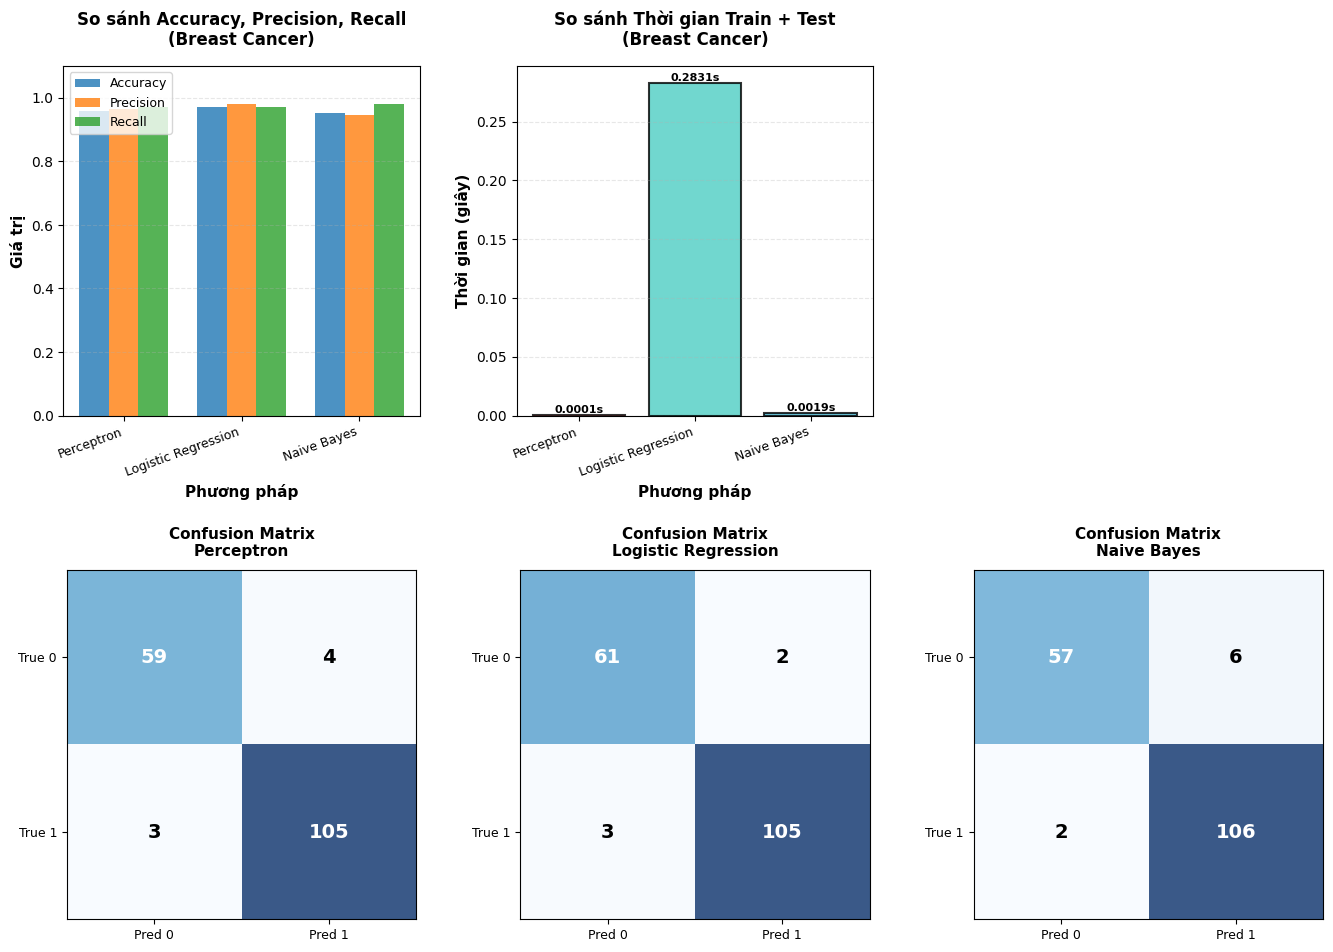

In [36]:
# Vẽ biểu đồ so sánh cho Ví dụ 3
fig = plt.figure(figsize=(14, 10))

methods_v3 = list(results_v3.keys())
colors_v3 = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# 1. So sánh Accuracy, Precision, Recall
ax1 = plt.subplot(2, 3, 1)
metrics_v3 = ['accuracy', 'precision', 'recall']
metric_labels_v3 = ['Accuracy', 'Precision', 'Recall']
x_v3 = np.arange(len(methods_v3))
width_v3 = 0.25

for i, metric in enumerate(metrics_v3):
    values_v3 = [results_v3[m][metric] for m in methods_v3]
    ax1.bar(x_v3 + i*width_v3, values_v3, width_v3, label=metric_labels_v3[i], alpha=0.8)

ax1.set_xlabel('Phương pháp', fontsize=11, fontweight='bold')
ax1.set_ylabel('Giá trị', fontsize=11, fontweight='bold')
ax1.set_title('So sánh Accuracy, Precision, Recall\n(Breast Cancer)', fontsize=12, fontweight='bold', pad=15)
ax1.set_xticks(x_v3 + width_v3)
ax1.set_xticklabels(methods_v3, rotation=20, ha='right', fontsize=9)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0, 1.1])

# 2. So sánh thời gian chạy
ax2 = plt.subplot(2, 3, 2)
times_v3 = [results_v3[m]['time'] for m in methods_v3]
bars_v3 = ax2.bar(methods_v3, times_v3, color=colors_v3, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Phương pháp', fontsize=11, fontweight='bold')
ax2.set_ylabel('Thời gian (giây)', fontsize=11, fontweight='bold')
ax2.set_title('So sánh Thời gian Train + Test\n(Breast Cancer)', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(range(len(methods_v3)))
ax2.set_xticklabels(methods_v3, rotation=20, ha='right', fontsize=9)
for bar, time_val in zip(bars_v3, times_v3):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.4f}s', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Confusion Matrix cho từng phương pháp
for idx, method in enumerate(methods_v3):
    ax = plt.subplot(2, 3, 4 + idx)
    
    cm = np.array([[results_v3[method]['TN'], results_v3[method]['FP']],
                   [results_v3[method]['FN'], results_v3[method]['TP']]])
    
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', alpha=0.8)
    
    # Ghi số vào các ô
    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', 
                   color=text_color, fontsize=14, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=9)
    ax.set_yticklabels(['True 0', 'True 1'], fontsize=9)
    ax.set_title(f'Confusion Matrix\n{method}', fontsize=11, fontweight='bold', pad=10)

plt.tight_layout(pad=3.0, w_pad=2.5, h_pad=3.0)
plt.show()

# Ví dụ 4 

## Load data

In [37]:
# Load dữ liệu Framingham
framingham_df = pd.read_csv('D:/Workspace/HUS/Machine Learning/7. Perceptron/framingham.csv')

print("="*70)
print("THÔNG TIN DỮ LIỆU FRAMINGHAM")
print("="*70)
print(f"\nKích thước ban đầu: {framingham_df.shape}")
print(f"Số lượng features: {framingham_df.shape[1] - 1}")
print(f"Số lượng samples: {framingham_df.shape[0]}")

print(f"\n5 dòng đầu tiên:")
print(framingham_df.head())

print(f"\nThông tin các cột:")
print(framingham_df.info())

print(f"\nSố lượng missing values theo cột:")
print(framingham_df.isnull().sum())

print(f"\nPhân phối target (TenYearCHD):")
print(framingham_df['TenYearCHD'].value_counts())
print(f"Tỷ lệ: {framingham_df['TenYearCHD'].value_counts(normalize=True)}")

# Loại bỏ các hàng có missing values
framingham_clean = framingham_df.dropna(how='any', axis=0).reset_index(drop=True)
print(f"\n{'='*70}")
print(f"Sau khi loại bỏ missing values: {framingham_clean.shape}")
print(f"Số samples còn lại: {framingham_clean.shape[0]} ({framingham_clean.shape[0]/framingham_df.shape[0]*100:.1f}%)")


THÔNG TIN DỮ LIỆU FRAMINGHAM

Kích thước ban đầu: (4238, 16)
Số lượng features: 15
Số lượng samples: 4238

5 dòng đầu tiên:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4     

## Preprocessing

In [38]:
# Chuẩn bị dữ liệu cho huấn luyện
# Phân tách features và target
X_framingham = framingham_clean.drop(columns=['TenYearCHD']).values
y_framingham = framingham_clean['TenYearCHD'].values

# Chia 7:3
from sklearn.model_selection import train_test_split
X_train_fram, X_val_fram, y_train_fram, y_val_fram = train_test_split(
    X_framingham, y_framingham, test_size=0.3, random_state=42, stratify=y_framingham
)

print("="*70)
print("CHIA DỮ LIỆU TRAIN:VALIDATION = 7:3")
print("="*70)
print(f"Training set: {X_train_fram.shape[0]} samples")
print(f"Validation set: {X_val_fram.shape[0]} samples")
print(f"\nPhân phối target trong training set:")
unique, counts = np.unique(y_train_fram, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} samples ({c/len(y_train_fram)*100:.1f}%)")
print(f"\nPhân phối target trong validation set:")
unique, counts = np.unique(y_val_fram, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} samples ({c/len(y_val_fram)*100:.1f}%)")

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler
scaler_fram = StandardScaler()
X_train_fram_scaled = scaler_fram.fit_transform(X_train_fram)
X_val_fram_scaled = scaler_fram.transform(X_val_fram)

print(f"\n Dữ liệu đã được chuẩn hóa (StandardScaler)")
print(f"  Mean của training set: {X_train_fram_scaled.mean(axis=0)[:3]} ...")
print(f"  Std của training set: {X_train_fram_scaled.std(axis=0)[:3]} ...")


CHIA DỮ LIỆU TRAIN:VALIDATION = 7:3
Training set: 2559 samples
Validation set: 1097 samples

Phân phối target trong training set:
  Class 0: 2169 samples (84.8%)
  Class 1: 390 samples (15.2%)

Phân phối target trong validation set:
  Class 0: 930 samples (84.8%)
  Class 1: 167 samples (15.2%)

 Dữ liệu đã được chuẩn hóa (StandardScaler)
  Mean của training set: [-1.63127729e-17 -1.79158499e-16 -1.90460300e-17] ...
  Std của training set: [1. 1. 1.] ...


## PCA Visualization

GIẢM CHIỀU DỮ LIỆU BẰNG PCA
Số chiều ban đầu: 15
Số chiều sau PCA: 2

Tỷ lệ phương sai giữ lại:
  PC1: 0.2152 (21.52%)
  PC2: 0.1255 (12.55%)
  Tổng: 0.3407 (34.07%)


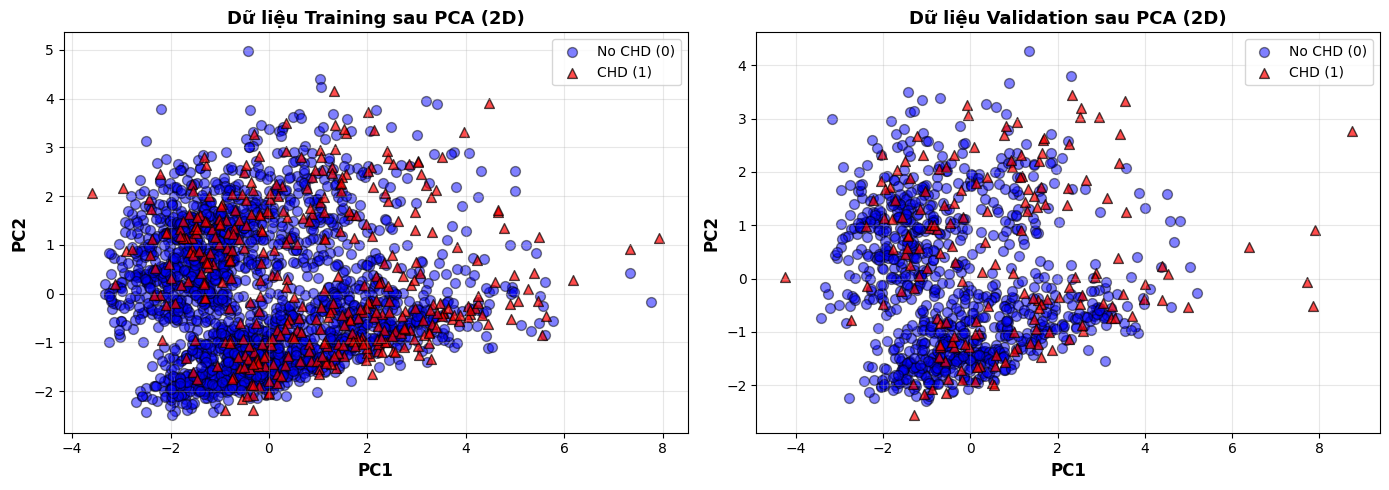


 Nhận xét:
  - Dữ liệu sau PCA có sự chồng lấn đáng kể giữa 2 class
  - Chỉ giữ được ~34.1% phương sai → có thể mất thông tin quan trọng
  - Dữ liệu không linearly separable hoàn toàn


In [39]:
# Giảm chiều xuống 2D bằng PCA
pca_fram = PCA(n_components=2)
X_train_fram_pca = pca_fram.fit_transform(X_train_fram_scaled)
X_val_fram_pca = pca_fram.transform(X_val_fram_scaled)

print("="*70)
print("GIẢM CHIỀU DỮ LIỆU BẰNG PCA")
print("="*70)
print(f"Số chiều ban đầu: {X_train_fram_scaled.shape[1]}")
print(f"Số chiều sau PCA: {X_train_fram_pca.shape[1]}")
print(f"\nTỷ lệ phương sai giữ lại:")
print(f"  PC1: {pca_fram.explained_variance_ratio_[0]:.4f} ({pca_fram.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  PC2: {pca_fram.explained_variance_ratio_[1]:.4f} ({pca_fram.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  Tổng: {pca_fram.explained_variance_ratio_.sum():.4f} ({pca_fram.explained_variance_ratio_.sum()*100:.2f}%)")

# Visualization dữ liệu sau PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
ax1 = axes[0]
ax1.scatter(X_train_fram_pca[y_train_fram==0, 0], X_train_fram_pca[y_train_fram==0, 1], 
           c='blue', marker='o', alpha=0.5, label='No CHD (0)', edgecolors='k', s=50)
ax1.scatter(X_train_fram_pca[y_train_fram==1, 0], X_train_fram_pca[y_train_fram==1, 1], 
           c='red', marker='^', alpha=0.7, label='CHD (1)', edgecolors='k', s=50)
ax1.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax1.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax1.set_title('Dữ liệu Training sau PCA (2D)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Validation set
ax2 = axes[1]
ax2.scatter(X_val_fram_pca[y_val_fram==0, 0], X_val_fram_pca[y_val_fram==0, 1], 
           c='blue', marker='o', alpha=0.5, label='No CHD (0)', edgecolors='k', s=50)
ax2.scatter(X_val_fram_pca[y_val_fram==1, 0], X_val_fram_pca[y_val_fram==1, 1], 
           c='red', marker='^', alpha=0.7, label='CHD (1)', edgecolors='k', s=50)
ax2.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax2.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax2.set_title('Dữ liệu Validation sau PCA (2D)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Nhận xét:")
print("  - Dữ liệu sau PCA có sự chồng lấn đáng kể giữa 2 class")
print("  - Chỉ giữ được ~{:.1f}% phương sai → có thể mất thông tin quan trọng".format(
    pca_fram.explained_variance_ratio_.sum()*100))
print("  - Dữ liệu không linearly separable hoàn toàn")


## Full data

### Perceptron

In [40]:
# Chuẩn bị dữ liệu cho Perceptron (dữ liệu đầy đủ)
# Chuyển target từ {0, 1} sang {-1, 1}
y_train_fram_perceptron = np.where(y_train_fram == 0, -1, 1)
y_val_fram_perceptron = np.where(y_val_fram == 0, -1, 1)

# Thêm bias term
x0_train_fram = np.ones((X_train_fram_scaled.shape[0], 1))
X_train_fram_with_bias = np.concatenate((x0_train_fram, X_train_fram_scaled), axis=1)

x0_val_fram = np.ones((X_val_fram_scaled.shape[0], 1))
X_val_fram_with_bias = np.concatenate((x0_val_fram, X_val_fram_scaled), axis=1)

# Transpose để phù hợp với hàm perceptron_general (features, samples)
X_train_fram_array = X_train_fram_with_bias.T
y_train_fram_array = y_train_fram_perceptron.reshape(1, -1)

# Khởi tạo và train Perceptron
print("="*70)
print("PERCEPTRON - DỮ LIỆU ĐẦY ĐỦ ({} features)".format(X_train_fram_scaled.shape[1]))
print("="*70)

d_fram = X_train_fram_array.shape[0]
w_init_fram = np.random.randn(d_fram, 1)

start_time_perc_full = time.time()
(w_trained_fram, mis_points_fram) = perceptron_general(
    X_train_fram_array, y_train_fram_array, w_init_fram, max_iter=1000, verbose=True
)
train_time_perc_full = time.time() - start_time_perc_full

print(f"\n Huấn luyện hoàn tất trong {train_time_perc_full:.4f} giây")
print(f"Số lần cập nhật trọng số: {len(w_trained_fram) - 1}")

# Test trên validation set
X_val_fram_array = X_val_fram_with_bias.T
y_val_fram_array = y_val_fram_perceptron.reshape(1, -1)

y_pred_perc_full = h(w_trained_fram[-1], X_val_fram_array)

# Tính metrics
TP_perc_full = np.sum((y_pred_perc_full == 1) & (y_val_fram_array == 1))
TN_perc_full = np.sum((y_pred_perc_full == -1) & (y_val_fram_array == -1))
FP_perc_full = np.sum((y_pred_perc_full == 1) & (y_val_fram_array == -1))
FN_perc_full = np.sum((y_pred_perc_full == -1) & (y_val_fram_array == 1))

acc_perc_full = (TP_perc_full + TN_perc_full) / (TP_perc_full + TN_perc_full + FP_perc_full + FN_perc_full)
prec_perc_full = TP_perc_full / (TP_perc_full + FP_perc_full) if (TP_perc_full + FP_perc_full) > 0 else 0
rec_perc_full = TP_perc_full / (TP_perc_full + FN_perc_full) if (TP_perc_full + FN_perc_full) > 0 else 0

print("\n" + "="*70)
print("KẾT QUẢ TRÊN VALIDATION SET")
print("="*70)
print(f"Accuracy:  {acc_perc_full:.4f} ({acc_perc_full*100:.2f}%)")
print(f"Precision: {prec_perc_full:.4f} ({prec_perc_full*100:.2f}%)")
print(f"Recall:    {rec_perc_full:.4f} ({rec_perc_full*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_perc_full}, FP={FP_perc_full}")
print(f"  FN={FN_perc_full}, TP={TP_perc_full}")

print(f"\n Ý nghĩa các hệ số:")
print(f"  - w0 (bias): {w_trained_fram[-1][0][0]:.4f}")
print(f"  - Mô hình có {d_fram-1} weights tương ứng với {d_fram-1} features")
print(f"  - Weight dương → tăng khả năng CHD, weight âm → giảm khả năng CHD")
top_features_idx = np.argsort(np.abs(w_trained_fram[-1][1:, 0]))[-5:][::-1]
print(f"  - Top 5 features quan trọng nhất (abs weight):")
feature_names = framingham_clean.drop(columns=['TenYearCHD']).columns
for idx in top_features_idx:
    print(f"    {feature_names[idx]}: {w_trained_fram[-1][idx+1][0]:.4f}")


PERCEPTRON - DỮ LIỆU ĐẦY ĐỦ (15 features)
Iteration 50/1000: Accuracy = 0.8163 (81.63%)
Iteration 50/1000: Accuracy = 0.8163 (81.63%)
Iteration 100/1000: Accuracy = 0.7233 (72.33%)
Iteration 100/1000: Accuracy = 0.7233 (72.33%)
Iteration 150/1000: Accuracy = 0.7538 (75.38%)
Iteration 150/1000: Accuracy = 0.7538 (75.38%)
Iteration 200/1000: Accuracy = 0.8367 (83.67%)
Iteration 200/1000: Accuracy = 0.8367 (83.67%)
Iteration 250/1000: Accuracy = 0.7620 (76.20%)
Iteration 250/1000: Accuracy = 0.7620 (76.20%)
Iteration 300/1000: Accuracy = 0.7284 (72.84%)
Iteration 300/1000: Accuracy = 0.7284 (72.84%)
Iteration 350/1000: Accuracy = 0.7659 (76.59%)
Iteration 350/1000: Accuracy = 0.7659 (76.59%)
Iteration 400/1000: Accuracy = 0.6803 (68.03%)
Iteration 400/1000: Accuracy = 0.6803 (68.03%)
Iteration 450/1000: Accuracy = 0.7585 (75.85%)
Iteration 450/1000: Accuracy = 0.7585 (75.85%)
Iteration 500/1000: Accuracy = 0.7214 (72.14%)
Iteration 500/1000: Accuracy = 0.7214 (72.14%)
Iteration 550/1000: 

### Logistic Regression

In [41]:
# Logistic Regression trên dữ liệu đầy đủ
print("="*70)
print("LOGISTIC REGRESSION - DỮ LIỆU ĐẦY ĐỦ ({} features)".format(X_train_fram_scaled.shape[1]))
print("="*70)

# Chuyển target về {0, 1} cho sklearn
lr_fram = LogisticRegression(max_iter=1000, random_state=42)

print(f"\nĐang huấn luyện Logistic Regression...")
start_time_lr_full = time.time()
lr_fram.fit(X_train_fram_scaled, y_train_fram)
train_time_lr_full = time.time() - start_time_lr_full

print(f"✓ Huấn luyện hoàn tất trong {train_time_lr_full:.4f} giây")

# Predict trên validation set
y_pred_lr_full = lr_fram.predict(X_val_fram_scaled)

# Tính metrics
TP_lr_full = np.sum((y_pred_lr_full == 1) & (y_val_fram == 1))
TN_lr_full = np.sum((y_pred_lr_full == 0) & (y_val_fram == 0))
FP_lr_full = np.sum((y_pred_lr_full == 1) & (y_val_fram == 0))
FN_lr_full = np.sum((y_pred_lr_full == 0) & (y_val_fram == 1))

acc_lr_full = (TP_lr_full + TN_lr_full) / (TP_lr_full + TN_lr_full + FP_lr_full + FN_lr_full)
prec_lr_full = TP_lr_full / (TP_lr_full + FP_lr_full) if (TP_lr_full + FP_lr_full) > 0 else 0
rec_lr_full = TP_lr_full / (TP_lr_full + FN_lr_full) if (TP_lr_full + FN_lr_full) > 0 else 0

print("\n" + "="*70)
print("KẾT QUẢ TRÊN VALIDATION SET")
print("="*70)
print(f"Accuracy:  {acc_lr_full:.4f} ({acc_lr_full*100:.2f}%)")
print(f"Precision: {prec_lr_full:.4f} ({prec_lr_full*100:.2f}%)")
print(f"Recall:    {rec_lr_full:.4f} ({rec_lr_full*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_lr_full}, FP={FP_lr_full}")
print(f"  FN={FN_lr_full}, TP={TP_lr_full}")

print(f"\n Ý nghĩa các hệ số:")
print(f"  - Intercept (w0): {lr_fram.intercept_[0]:.4f}")
print(f"  - Mô hình có {len(lr_fram.coef_[0])} coefficients")
print(f"  - Coefficient dương → tăng log-odds của CHD, âm → giảm log-odds")
top_coef_idx = np.argsort(np.abs(lr_fram.coef_[0]))[-5:][::-1]
print(f"  - Top 5 features quan trọng nhất (abs coefficient):")
for idx in top_coef_idx:
    print(f"    {feature_names[idx]}: {lr_fram.coef_[0][idx]:.4f}")


LOGISTIC REGRESSION - DỮ LIỆU ĐẦY ĐỦ (15 features)

Đang huấn luyện Logistic Regression...
✓ Huấn luyện hoàn tất trong 0.0081 giây

KẾT QUẢ TRÊN VALIDATION SET
Accuracy:  0.8587 (85.87%)
Precision: 0.7727 (77.27%)
Recall:    0.1018 (10.18%)

Confusion Matrix:
  TN=925, FP=5
  FN=150, TP=17

 Ý nghĩa các hệ số:
  - Intercept (w0): -1.9825
  - Mô hình có 15 coefficients
  - Coefficient dương → tăng log-odds của CHD, âm → giảm log-odds
  - Top 5 features quan trọng nhất (abs coefficient):
    age: 0.5181
    sysBP: 0.3233
    male: 0.2403
    cigsPerDay: 0.2036
    glucose: 0.1478


### Naive Bayes

In [42]:
# Naive Bayes trên dữ liệu đầy đủ
print("="*70)
print("NAIVE BAYES - DỮ LIỆU ĐẦY ĐỦ ({} features)".format(X_train_fram_scaled.shape[1]))
print("="*70)

nb_fram = GaussianNB()

print(f"\nĐang huấn luyện Naive Bayes...")
start_time_nb_full = time.time()
nb_fram.fit(X_train_fram_scaled, y_train_fram)
train_time_nb_full = time.time() - start_time_nb_full

print(f" Huấn luyện hoàn tất trong {train_time_nb_full:.4f} giây")

# Predict trên validation set
y_pred_nb_full = nb_fram.predict(X_val_fram_scaled)

# Tính metrics
TP_nb_full = np.sum((y_pred_nb_full == 1) & (y_val_fram == 1))
TN_nb_full = np.sum((y_pred_nb_full == 0) & (y_val_fram == 0))
FP_nb_full = np.sum((y_pred_nb_full == 1) & (y_val_fram == 0))
FN_nb_full = np.sum((y_pred_nb_full == 0) & (y_val_fram == 1))

acc_nb_full = (TP_nb_full + TN_nb_full) / (TP_nb_full + TN_nb_full + FP_nb_full + FN_nb_full)
prec_nb_full = TP_nb_full / (TP_nb_full + FP_nb_full) if (TP_nb_full + FP_nb_full) > 0 else 0
rec_nb_full = TP_nb_full / (TP_nb_full + FN_nb_full) if (TP_nb_full + FN_nb_full) > 0 else 0

print("\n" + "="*70)
print("KẾT QUẢ TRÊN VALIDATION SET")
print("="*70)
print(f"Accuracy:  {acc_nb_full:.4f} ({acc_nb_full*100:.2f}%)")
print(f"Precision: {prec_nb_full:.4f} ({prec_nb_full*100:.2f}%)")
print(f"Recall:    {rec_nb_full:.4f} ({rec_nb_full*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_nb_full}, FP={FP_nb_full}")
print(f"  FN={FN_nb_full}, TP={TP_nb_full}")

NAIVE BAYES - DỮ LIỆU ĐẦY ĐỦ (15 features)

Đang huấn luyện Naive Bayes...
 Huấn luyện hoàn tất trong 0.0017 giây

KẾT QUẢ TRÊN VALIDATION SET
Accuracy:  0.8377 (83.77%)
Precision: 0.4368 (43.68%)
Recall:    0.2275 (22.75%)

Confusion Matrix:
  TN=881, FP=49
  FN=129, TP=38


### So sánh các phương pháp trên full data

In [43]:
# So sánh 3 phương pháp
print("\n" + "="*70)
print("SO SÁNH 3 PHƯƠNG PHÁP TRÊN DỮ LIỆU ĐẦY ĐỦ")
print("="*70)

results_full = {
    'Perceptron': {
        'Accuracy': acc_perc_full,
        'Precision': prec_perc_full,
        'Recall': rec_perc_full,
        'Time (s)': train_time_perc_full
    },
    'Logistic Regression': {
        'Accuracy': acc_lr_full,
        'Precision': prec_lr_full,
        'Recall': rec_lr_full,
        'Time (s)': train_time_lr_full
    },
    'Naive Bayes': {
        'Accuracy': acc_nb_full,
        'Precision': prec_nb_full,
        'Recall': rec_nb_full,
        'Time (s)': train_time_nb_full
    }
}

df_full = pd.DataFrame(results_full).T
print("\n", df_full.to_string())

print("\n" + "="*70)
print("PHƯƠNG PHÁP TỐT NHẤT TRÊN DỮ LIỆU ĐẦY ĐỦ")
print("="*70)
print(f"Accuracy cao nhất:  {df_full['Accuracy'].idxmax()} ({df_full['Accuracy'].max():.4f})")
print(f"Precision cao nhất: {df_full['Precision'].idxmax()} ({df_full['Precision'].max():.4f})")
print(f"Recall cao nhất:    {df_full['Recall'].idxmax()} ({df_full['Recall'].max():.4f})")
print(f"Nhanh nhất:         {df_full['Time (s)'].idxmin()} ({df_full['Time (s)'].min():.4f}s)")



SO SÁNH 3 PHƯƠNG PHÁP TRÊN DỮ LIỆU ĐẦY ĐỦ

                      Accuracy  Precision    Recall   Time (s)
Perceptron           0.770283   0.245509  0.245509  12.864658
Logistic Regression  0.858706   0.772727  0.101796   0.008060
Naive Bayes          0.837739   0.436782  0.227545   0.001709

PHƯƠNG PHÁP TỐT NHẤT TRÊN DỮ LIỆU ĐẦY ĐỦ
Accuracy cao nhất:  Logistic Regression (0.8587)
Precision cao nhất: Logistic Regression (0.7727)
Recall cao nhất:    Perceptron (0.2455)
Nhanh nhất:         Naive Bayes (0.0017s)


## PCA

### Perceptron

In [44]:
# Perceptron trên dữ liệu PCA (2 chiều)
print("="*70)
print("PERCEPTRON - DỮ LIỆU PCA (2 chiều)")
print("="*70)

# Chuẩn bị dữ liệu
x0_train_pca = np.ones((X_train_fram_pca.shape[0], 1))
X_train_pca_with_bias = np.concatenate((x0_train_pca, X_train_fram_pca), axis=1)

x0_val_pca = np.ones((X_val_fram_pca.shape[0], 1))
X_val_pca_with_bias = np.concatenate((x0_val_pca, X_val_fram_pca), axis=1)

# Transpose
X_train_pca_array = X_train_pca_with_bias.T
y_train_pca_array = y_train_fram_perceptron.reshape(1, -1)

# Train
d_pca = X_train_pca_array.shape[0]
w_init_pca = np.random.randn(d_pca, 1)

print(f"\nĐang huấn luyện Perceptron với {d_pca-1} features PCA (+ bias)...")
start_time_perc_pca = time.time()
(w_trained_pca, mis_points_pca) = perceptron_general(
    X_train_pca_array, y_train_pca_array, w_init_pca, max_iter=1000, verbose=True
)
train_time_perc_pca = time.time() - start_time_perc_pca

print(f"\nHuấn luyện hoàn tất trong {train_time_perc_pca:.4f} giây")

# Test
X_val_pca_array = X_val_pca_with_bias.T
y_val_pca_array = y_val_fram_perceptron.reshape(1, -1)
y_pred_perc_pca = h(w_trained_pca[-1], X_val_pca_array)

# Metrics
TP_perc_pca = np.sum((y_pred_perc_pca == 1) & (y_val_pca_array == 1))
TN_perc_pca = np.sum((y_pred_perc_pca == -1) & (y_val_pca_array == -1))
FP_perc_pca = np.sum((y_pred_perc_pca == 1) & (y_val_pca_array == -1))
FN_perc_pca = np.sum((y_pred_perc_pca == -1) & (y_val_pca_array == 1))

acc_perc_pca = (TP_perc_pca + TN_perc_pca) / (TP_perc_pca + TN_perc_pca + FP_perc_pca + FN_perc_pca)
prec_perc_pca = TP_perc_pca / (TP_perc_pca + FP_perc_pca) if (TP_perc_pca + FP_perc_pca) > 0 else 0
rec_perc_pca = TP_perc_pca / (TP_perc_pca + FN_perc_pca) if (TP_perc_pca + FN_perc_pca) > 0 else 0

print("\n" + "="*70)
print("KẾT QUẢ TRÊN VALIDATION SET (PCA)")
print("="*70)
print(f"Accuracy:  {acc_perc_pca:.4f} ({acc_perc_pca*100:.2f}%)")
print(f"Precision: {prec_perc_pca:.4f} ({prec_perc_pca*100:.2f}%)")
print(f"Recall:    {rec_perc_pca:.4f} ({rec_perc_pca*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_perc_pca}, FP={FP_perc_pca}")
print(f"  FN={FN_perc_pca}, TP={TP_perc_pca}")


PERCEPTRON - DỮ LIỆU PCA (2 chiều)

Đang huấn luyện Perceptron với 2 features PCA (+ bias)...
Iteration 50/1000: Accuracy = 0.8468 (84.68%)
Iteration 50/1000: Accuracy = 0.8468 (84.68%)
Iteration 100/1000: Accuracy = 0.8226 (82.26%)
Iteration 100/1000: Accuracy = 0.8226 (82.26%)
Iteration 150/1000: Accuracy = 0.8191 (81.91%)
Iteration 150/1000: Accuracy = 0.8191 (81.91%)
Iteration 200/1000: Accuracy = 0.6866 (68.66%)
Iteration 200/1000: Accuracy = 0.6866 (68.66%)
Iteration 250/1000: Accuracy = 0.8476 (84.76%)
Iteration 250/1000: Accuracy = 0.8476 (84.76%)
Iteration 300/1000: Accuracy = 0.8300 (83.00%)
Iteration 300/1000: Accuracy = 0.8300 (83.00%)
Iteration 350/1000: Accuracy = 0.8476 (84.76%)
Iteration 350/1000: Accuracy = 0.8476 (84.76%)
Iteration 400/1000: Accuracy = 0.6323 (63.23%)
Iteration 400/1000: Accuracy = 0.6323 (63.23%)
Iteration 450/1000: Accuracy = 0.8367 (83.67%)
Iteration 450/1000: Accuracy = 0.8367 (83.67%)
Iteration 500/1000: Accuracy = 0.8187 (81.87%)
Iteration 500/1

### Logistic Regression

In [45]:
# Logistic Regression trên dữ liệu PCA
print("="*70)
print("LOGISTIC REGRESSION - DỮ LIỆU PCA (2 chiều)")
print("="*70)

lr_pca = LogisticRegression(max_iter=1000, random_state=42)

print(f"\nĐang huấn luyện Logistic Regression trên PCA...")
start_time_lr_pca = time.time()
lr_pca.fit(X_train_fram_pca, y_train_fram)
train_time_lr_pca = time.time() - start_time_lr_pca

print(f"✓ Huấn luyện hoàn tất trong {train_time_lr_pca:.4f} giây")

# Predict
y_pred_lr_pca = lr_pca.predict(X_val_fram_pca)

# Metrics
TP_lr_pca = np.sum((y_pred_lr_pca == 1) & (y_val_fram == 1))
TN_lr_pca = np.sum((y_pred_lr_pca == 0) & (y_val_fram == 0))
FP_lr_pca = np.sum((y_pred_lr_pca == 1) & (y_val_fram == 0))
FN_lr_pca = np.sum((y_pred_lr_pca == 0) & (y_val_fram == 1))

acc_lr_pca = (TP_lr_pca + TN_lr_pca) / (TP_lr_pca + TN_lr_pca + FP_lr_pca + FN_lr_pca)
prec_lr_pca = TP_lr_pca / (TP_lr_pca + FP_lr_pca) if (TP_lr_pca + FP_lr_pca) > 0 else 0
rec_lr_pca = TP_lr_pca / (TP_lr_pca + FN_lr_pca) if (TP_lr_pca + FN_lr_pca) > 0 else 0

print("\n" + "="*70)
print("KẾT QUẢ TRÊN VALIDATION SET (PCA)")
print("="*70)
print(f"Accuracy:  {acc_lr_pca:.4f} ({acc_lr_pca*100:.2f}%)")
print(f"Precision: {prec_lr_pca:.4f} ({prec_lr_pca*100:.2f}%)")
print(f"Recall:    {rec_lr_pca:.4f} ({rec_lr_pca*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_lr_pca}, FP={FP_lr_pca}")
print(f"  FN={FN_lr_pca}, TP={TP_lr_pca}")


LOGISTIC REGRESSION - DỮ LIỆU PCA (2 chiều)

Đang huấn luyện Logistic Regression trên PCA...
✓ Huấn luyện hoàn tất trong 0.0031 giây

KẾT QUẢ TRÊN VALIDATION SET (PCA)
Accuracy:  0.8523 (85.23%)
Precision: 1.0000 (100.00%)
Recall:    0.0299 (2.99%)

Confusion Matrix:
  TN=930, FP=0
  FN=162, TP=5


### Naive Bayes

In [46]:
# Naive Bayes trên dữ liệu PCA
print("="*70)
print("NAIVE BAYES - DỮ LIỆU PCA (2 chiều)")
print("="*70)

nb_pca = GaussianNB()

print(f"\nĐang huấn luyện Naive Bayes trên PCA...")
start_time_nb_pca = time.time()
nb_pca.fit(X_train_fram_pca, y_train_fram)
train_time_nb_pca = time.time() - start_time_nb_pca

print(f"✓ Huấn luyện hoàn tất trong {train_time_nb_pca:.4f} giây")

# Predict
y_pred_nb_pca = nb_pca.predict(X_val_fram_pca)

# Metrics
TP_nb_pca = np.sum((y_pred_nb_pca == 1) & (y_val_fram == 1))
TN_nb_pca = np.sum((y_pred_nb_pca == 0) & (y_val_fram == 0))
FP_nb_pca = np.sum((y_pred_nb_pca == 1) & (y_val_fram == 0))
FN_nb_pca = np.sum((y_pred_nb_pca == 0) & (y_val_fram == 1))

acc_nb_pca = (TP_nb_pca + TN_nb_pca) / (TP_nb_pca + TN_nb_pca + FP_nb_pca + FN_nb_pca)
prec_nb_pca = TP_nb_pca / (TP_nb_pca + FP_nb_pca) if (TP_nb_pca + FP_nb_pca) > 0 else 0
rec_nb_pca = TP_nb_pca / (TP_nb_pca + FN_nb_pca) if (TP_nb_pca + FN_nb_pca) > 0 else 0

print("\n" + "="*70)
print("KẾT QUẢ TRÊN VALIDATION SET (PCA)")
print("="*70)
print(f"Accuracy:  {acc_nb_pca:.4f} ({acc_nb_pca*100:.2f}%)")
print(f"Precision: {prec_nb_pca:.4f} ({prec_nb_pca*100:.2f}%)")
print(f"Recall:    {rec_nb_pca:.4f} ({rec_nb_pca*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_nb_pca}, FP={FP_nb_pca}")
print(f"  FN={FN_nb_pca}, TP={TP_nb_pca}")

NAIVE BAYES - DỮ LIỆU PCA (2 chiều)

Đang huấn luyện Naive Bayes trên PCA...
✓ Huấn luyện hoàn tất trong 0.0061 giây

KẾT QUẢ TRÊN VALIDATION SET (PCA)
Accuracy:  0.8496 (84.96%)
Precision: 0.5417 (54.17%)
Recall:    0.0778 (7.78%)

Confusion Matrix:
  TN=919, FP=11
  FN=154, TP=13


### So sánh các phương pháp trên PCA

In [47]:
# So sánh 3 phương pháp trên PCA
print("\n" + "="*70)
print("SO SÁNH 3 PHƯƠNG PHÁP TRÊN DỮ LIỆU PCA (2 CHIỀU)")
print("="*70)

results_pca = {
    'Perceptron': {
        'Accuracy': acc_perc_pca,
        'Precision': prec_perc_pca,
        'Recall': rec_perc_pca,
        'Time (s)': train_time_perc_pca
    },
    'Logistic Regression': {
        'Accuracy': acc_lr_pca,
        'Precision': prec_lr_pca,
        'Recall': rec_lr_pca,
        'Time (s)': train_time_lr_pca
    },
    'Naive Bayes': {
        'Accuracy': acc_nb_pca,
        'Precision': prec_nb_pca,
        'Recall': rec_nb_pca,
        'Time (s)': train_time_nb_pca
    }
}

df_pca = pd.DataFrame(results_pca).T
print("\n", df_pca.to_string())

print("\n" + "="*70)
print("PHƯƠNG PHÁP TỐT NHẤT TRÊN DỮ LIỆU PCA")
print("="*70)
print(f"Accuracy cao nhất:  {df_pca['Accuracy'].idxmax()} ({df_pca['Accuracy'].max():.4f})")
print(f"Precision cao nhất: {df_pca['Precision'].idxmax()} ({df_pca['Precision'].max():.4f})")
print(f"Recall cao nhất:    {df_pca['Recall'].idxmax()} ({df_pca['Recall'].max():.4f})")
print(f"Nhanh nhất:         {df_pca['Time (s)'].idxmin()} ({df_pca['Time (s)'].min():.4f}s)")



SO SÁNH 3 PHƯƠNG PHÁP TRÊN DỮ LIỆU PCA (2 CHIỀU)

                      Accuracy  Precision    Recall   Time (s)
Perceptron           0.782133   0.283133  0.281437  12.940040
Logistic Regression  0.852325   1.000000  0.029940   0.003060
Naive Bayes          0.849590   0.541667  0.077844   0.006076

PHƯƠNG PHÁP TỐT NHẤT TRÊN DỮ LIỆU PCA
Accuracy cao nhất:  Logistic Regression (0.8523)
Precision cao nhất: Logistic Regression (1.0000)
Recall cao nhất:    Perceptron (0.2814)
Nhanh nhất:         Logistic Regression (0.0031s)


## So sánh tổng thể các phương pháp trên Full data và PCA

In [48]:
# So sánh tổng thể: Full features vs PCA
print("="*80)
print("SO SÁNH TỔNG QUAN: DỮ LIỆU ĐẦY ĐỦ vs DỮ LIỆU PCA")
print("="*80)

# Tạo DataFrame so sánh cho từng phương pháp
print("\n" + "="*80)
print("1. PERCEPTRON")
print("="*80)
perc_comparison = pd.DataFrame({
    'Full Features': [acc_perc_full, prec_perc_full, rec_perc_full, train_time_perc_full],
    'PCA (2D)': [acc_perc_pca, prec_perc_pca, rec_perc_pca, train_time_perc_pca],
    'Difference': [
        acc_perc_full - acc_perc_pca,
        prec_perc_full - prec_perc_pca,
        rec_perc_full - rec_perc_pca,
        train_time_perc_full - train_time_perc_pca
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'Time (s)'])
print(perc_comparison.to_string())

print("\n" + "="*80)
print("2. LOGISTIC REGRESSION")
print("="*80)
lr_comparison = pd.DataFrame({
    'Full Features': [acc_lr_full, prec_lr_full, rec_lr_full, train_time_lr_full],
    'PCA (2D)': [acc_lr_pca, prec_lr_pca, rec_lr_pca, train_time_lr_pca],
    'Difference': [
        acc_lr_full - acc_lr_pca,
        prec_lr_full - prec_lr_pca,
        rec_lr_full - rec_lr_pca,
        train_time_lr_full - train_time_lr_pca
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'Time (s)'])
print(lr_comparison.to_string())

print("\n" + "="*80)
print("3. NAIVE BAYES")
print("="*80)
nb_comparison = pd.DataFrame({
    'Full Features': [acc_nb_full, prec_nb_full, rec_nb_full, train_time_nb_full],
    'PCA (2D)': [acc_nb_pca, prec_nb_pca, rec_nb_pca, train_time_nb_pca],
    'Difference': [
        acc_nb_full - acc_nb_pca,
        prec_nb_full - prec_nb_pca,
        rec_nb_full - rec_nb_pca,
        train_time_nb_full - train_time_nb_pca
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'Time (s)'])
print(nb_comparison.to_string())

# Phân tích mô hình bị ảnh hưởng nhiều nhất
print("\n" + "="*80)
print("PHÂN TÍCH ẢNH HƯỞNG CỦA GIẢM CHIỀU")
print("="*80)

acc_drops = {
    'Perceptron': abs(acc_perc_full - acc_perc_pca),
    'Logistic Regression': abs(acc_lr_full - acc_lr_pca),
    'Naive Bayes': abs(acc_nb_full - acc_nb_pca)
}

most_affected = max(acc_drops, key=acc_drops.get)
least_affected = min(acc_drops, key=acc_drops.get)

print(f"\n Suy giảm Accuracy khi giảm chiều:")
for model, drop in acc_drops.items():
    print(f"  {model:<22}: {drop:.4f} ({drop*100:.2f}%)")

print(f"\n  Mô hình bị ảnh hưởng NHIỀU NHẤT: {most_affected}")
print(f"    Suy giảm accuracy: {acc_drops[most_affected]:.4f} ({acc_drops[most_affected]*100:.2f}%)")

print(f"\n✓ Mô hình bị ảnh hưởng ÍT NHẤT: {least_affected}")
print(f"    Suy giảm accuracy: {acc_drops[least_affected]:.4f} ({acc_drops[least_affected]*100:.2f}%)")


SO SÁNH TỔNG QUAN: DỮ LIỆU ĐẦY ĐỦ vs DỮ LIỆU PCA

1. PERCEPTRON
           Full Features   PCA (2D)  Difference
Accuracy        0.770283   0.782133   -0.011851
Precision       0.245509   0.283133   -0.037624
Recall          0.245509   0.281437   -0.035928
Time (s)       12.864658  12.940040   -0.075382

2. LOGISTIC REGRESSION
           Full Features  PCA (2D)  Difference
Accuracy        0.858706  0.852325    0.006381
Precision       0.772727  1.000000   -0.227273
Recall          0.101796  0.029940    0.071856
Time (s)        0.008060  0.003060    0.005000

3. NAIVE BAYES
           Full Features  PCA (2D)  Difference
Accuracy        0.837739  0.849590   -0.011851
Precision       0.436782  0.541667   -0.104885
Recall          0.227545  0.077844    0.149701
Time (s)        0.001709  0.006076   -0.004367

PHÂN TÍCH ẢNH HƯỞNG CỦA GIẢM CHIỀU

 Suy giảm Accuracy khi giảm chiều:
  Perceptron            : 0.0119 (1.19%)
  Logistic Regression   : 0.0064 (0.64%)
  Naive Bayes           : 0.0119

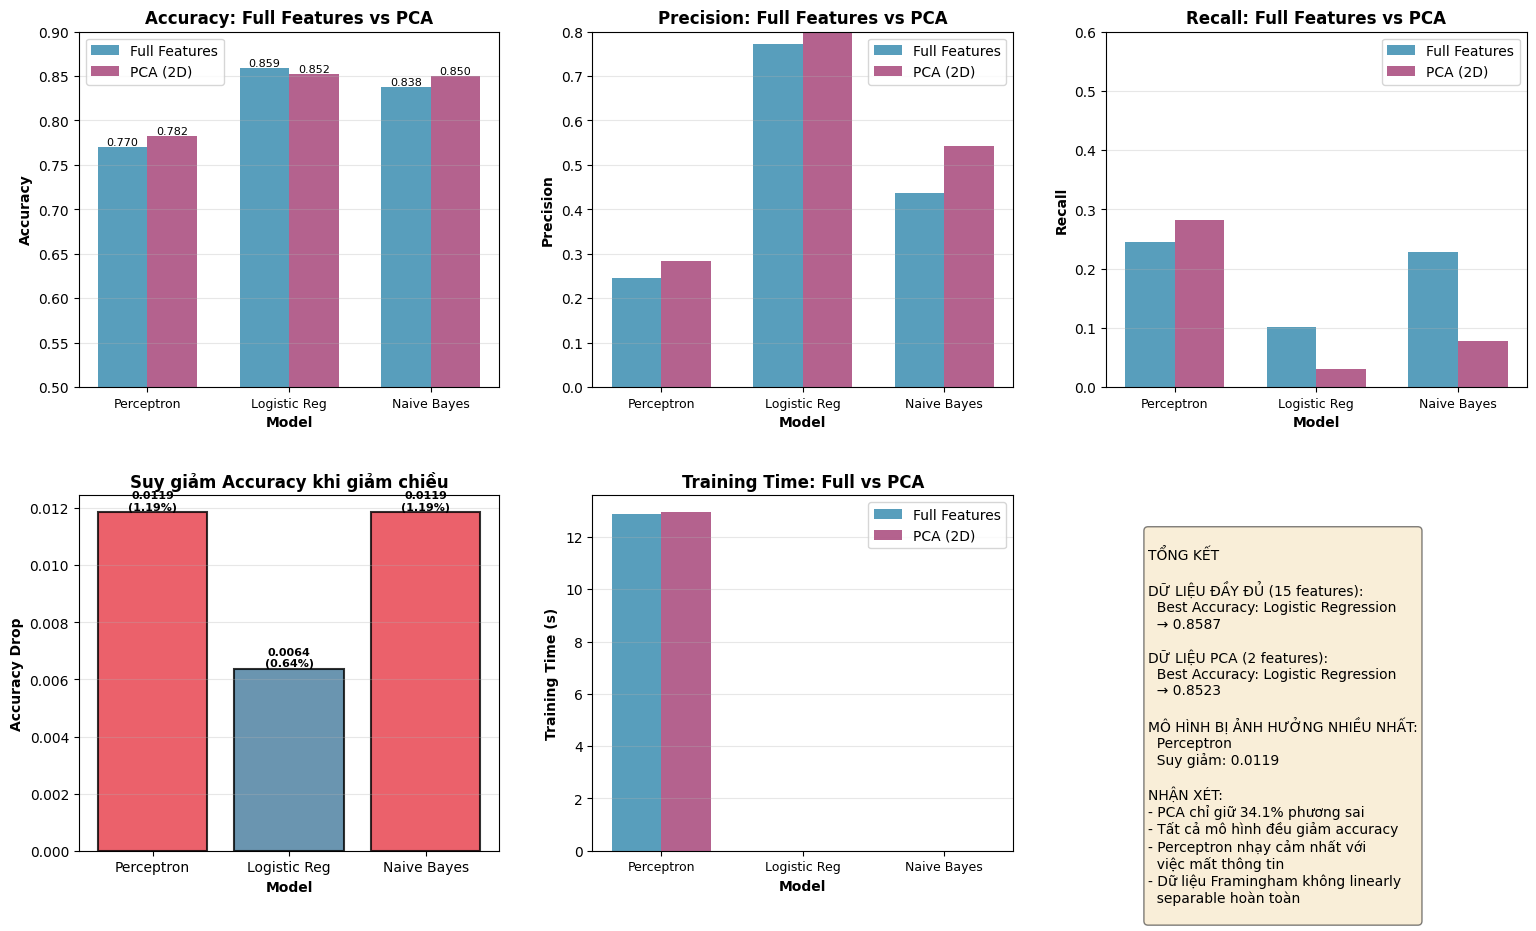

In [49]:
# Visualization so sánh
fig = plt.figure(figsize=(16, 10))

# 1. So sánh Accuracy: Full vs PCA
ax1 = plt.subplot(2, 3, 1)
models = ['Perceptron', 'Logistic Reg', 'Naive Bayes']
acc_full = [acc_perc_full, acc_lr_full, acc_nb_full]
acc_pca = [acc_perc_pca, acc_lr_pca, acc_nb_pca]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, acc_full, width, label='Full Features', alpha=0.8, color='#2E86AB')
bars2 = ax1.bar(x + width/2, acc_pca, width, label='PCA (2D)', alpha=0.8, color='#A23B72')

ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Accuracy: Full Features vs PCA', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=9)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.5, 0.9])

# Thêm giá trị lên bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 2. So sánh Precision
ax2 = plt.subplot(2, 3, 2)
prec_full = [prec_perc_full, prec_lr_full, prec_nb_full]
prec_pca = [prec_perc_pca, prec_lr_pca, prec_nb_pca]

bars1 = ax2.bar(x - width/2, prec_full, width, label='Full Features', alpha=0.8, color='#2E86AB')
bars2 = ax2.bar(x + width/2, prec_pca, width, label='PCA (2D)', alpha=0.8, color='#A23B72')

ax2.set_xlabel('Model', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision: Full Features vs PCA', fontweight='bold', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=9)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 0.8])

# 3. So sánh Recall
ax3 = plt.subplot(2, 3, 3)
rec_full = [rec_perc_full, rec_lr_full, rec_nb_full]
rec_pca = [rec_perc_pca, rec_lr_pca, rec_nb_pca]

bars1 = ax3.bar(x - width/2, rec_full, width, label='Full Features', alpha=0.8, color='#2E86AB')
bars2 = ax3.bar(x + width/2, rec_pca, width, label='PCA (2D)', alpha=0.8, color='#A23B72')

ax3.set_xlabel('Model', fontweight='bold')
ax3.set_ylabel('Recall', fontweight='bold')
ax3.set_title('Recall: Full Features vs PCA', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(models, fontsize=9)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0, 0.6])

# 4. Suy giảm Accuracy
ax4 = plt.subplot(2, 3, 4)
acc_drop = [abs(acc_perc_full - acc_perc_pca), abs(acc_lr_full - acc_lr_pca), abs(acc_nb_full - acc_nb_pca)]
colors_drop = ['#E63946' if drop == max(acc_drop) else '#457B9D' for drop in acc_drop]
bars = ax4.bar(models, acc_drop, alpha=0.8, color=colors_drop, edgecolor='black', linewidth=1.5)

ax4.set_xlabel('Model', fontweight='bold')
ax4.set_ylabel('Accuracy Drop', fontweight='bold')
ax4.set_title('Suy giảm Accuracy khi giảm chiều', fontweight='bold', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

for bar, drop_val in zip(bars, acc_drop):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{drop_val:.4f}\n({drop_val*100:.2f}%)', 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# 5. So sánh thời gian
ax5 = plt.subplot(2, 3, 5)
time_full = [train_time_perc_full, train_time_lr_full, train_time_nb_full]
time_pca = [train_time_perc_pca, train_time_lr_pca, train_time_nb_pca]

bars1 = ax5.bar(x - width/2, time_full, width, label='Full Features', alpha=0.8, color='#2E86AB')
bars2 = ax5.bar(x + width/2, time_pca, width, label='PCA (2D)', alpha=0.8, color='#A23B72')

ax5.set_xlabel('Model', fontweight='bold')
ax5.set_ylabel('Training Time (s)', fontweight='bold')
ax5.set_title('Training Time: Full vs PCA', fontweight='bold', fontsize=12)
ax5.set_xticks(x)
ax5.set_xticklabels(models, fontsize=9)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# 6. Tổng quan Best Model
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

summary_text = f"""
TỔNG KẾT

DỮ LIỆU ĐẦY ĐỦ ({X_train_fram_scaled.shape[1]} features):
  Best Accuracy: {df_full['Accuracy'].idxmax()}
  → {df_full['Accuracy'].max():.4f}

DỮ LIỆU PCA (2 features):
  Best Accuracy: {df_pca['Accuracy'].idxmax()}
  → {df_pca['Accuracy'].max():.4f}

MÔ HÌNH BỊ ẢNH HƯỞNG NHIỀU NHẤT:
  {most_affected}
  Suy giảm: {acc_drops[most_affected]:.4f}

NHẬN XÉT:
- PCA chỉ giữ {pca_fram.explained_variance_ratio_.sum()*100:.1f}% phương sai
- Tất cả mô hình đều giảm accuracy
- {most_affected} nhạy cảm nhất với
  việc mất thông tin
- Dữ liệu Framingham không linearly
  separable hoàn toàn
"""

ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(pad=3.0)
plt.show()


# Ví dụ 5

In [50]:
# Load dữ liệu Portfolio
print("="*80)
print("LOAD DỮ LIỆU ANALYSIS-PORTFOLIO-TASK-DATA")
print("="*80)

portfolio_df = pd.read_csv('D:/Workspace/HUS/Machine Learning/7. Perceptron/Analysis-Portfolio-Task-Data.csv')

print(f"\nKích thước dữ liệu: {portfolio_df.shape}")
print(f"Số lượng bản ghi: {len(portfolio_df)}")
print(f"\nThông tin các cột:")
print(portfolio_df.info())

print(f"\n{'='*80}")
print("MẪU DỮ LIỆU (5 dòng đầu)")
print("="*80)
print(portfolio_df.head())

print(f"\n{'='*80}")
print("THỐNG KÊ MÔ TẢ")
print("="*80)
print(portfolio_df.describe())

print(f"\n{'='*80}")
print("KIỂM TRA GIÁ TRỊ NULL")
print("="*80)
print(portfolio_df.isnull().sum())

print(f"\n{'='*80}")
print("GIÁ TRỊ DUY NHẤT CỦA CÁC BIẾN CATEGORICAL")
print("="*80)
print(f"Gender: {portfolio_df['Gender'].unique()}")
print(f"Store Type: {portfolio_df['Store Type'].unique()}")

LOAD DỮ LIỆU ANALYSIS-PORTFOLIO-TASK-DATA

Kích thước dữ liệu: (75, 8)
Số lượng bản ghi: 75

Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           75 non-null     int64  
 1   Shopping Basket      75 non-null     float64
 2   Gender               75 non-null     object 
 3   Age                  75 non-null     int64  
 4   Store Type           75 non-null     object 
 5   Value Products       75 non-null     int64  
 6   Brand Products       75 non-null     int64  
 7   Top Fresco Products  75 non-null     int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 4.8+ KB
None

MẪU DỮ LIỆU (5 dòng đầu)
   CustomerID  Shopping Basket  Gender  Age         Store Type  \
0    20358063            48.81    Male   26  Convenient Stores   
1    24635139            33.44  Female   33         Superstor

In [51]:
# Chuẩn hóa dữ liệu
print("="*80)
print("CHUẨN HÓA DỮ LIỆU")
print("="*80)

# Tạo bản sao để xử lý
portfolio_clean = portfolio_df.copy()

# 1. Encode Gender: Male=1, Female=0
print("\n1. Encoding Gender:")
print(f"   Before: {portfolio_clean['Gender'].unique()}")
portfolio_clean['Gender'] = portfolio_clean['Gender'].map({'Male': 1, 'Female': 0})
print(f"   After: {portfolio_clean['Gender'].unique()}")

# 2. Encode Store Type: One-hot encoding
print("\n2. Encoding Store Type (One-hot encoding):")
print(f"   Original values: {portfolio_df['Store Type'].unique()}")

# One-hot encoding cho Store Type
store_type_dummies = pd.get_dummies(portfolio_df['Store Type'], prefix='StoreType')
print(f"   Created columns: {list(store_type_dummies.columns)}")

# Thêm các cột one-hot vào dataframe
portfolio_clean = pd.concat([portfolio_clean, store_type_dummies], axis=1)

# Xóa cột Store Type gốc
portfolio_clean = portfolio_clean.drop('Store Type', axis=1)

print(f"\n3. Loại bỏ CustomerID (không dùng cho mô hình):")
portfolio_clean = portfolio_clean.drop('CustomerID', axis=1)

print(f"\n{'='*80}")
print("DỮ LIỆU SAU CHUẨN HÓA")
print("="*80)
print(f"Kích thước: {portfolio_clean.shape}")
print(f"Các cột: {list(portfolio_clean.columns)}")
print("\nMẫu dữ liệu:")
print(portfolio_clean.head())

print(f"\n{'='*80}")
print("THỐNG KÊ DỮ LIỆU ĐÃ CHUẨN HÓA")
print("="*80)
print(portfolio_clean.describe())

CHUẨN HÓA DỮ LIỆU

1. Encoding Gender:
   Before: ['Male' 'Female']
   After: [1 0]

2. Encoding Store Type (One-hot encoding):
   Original values: ['Convenient Stores' 'Superstore' 'Online']
   Created columns: ['StoreType_Convenient Stores', 'StoreType_Online', 'StoreType_Superstore']

3. Loại bỏ CustomerID (không dùng cho mô hình):

DỮ LIỆU SAU CHUẨN HÓA
Kích thước: (75, 9)
Các cột: ['Shopping Basket', 'Gender', 'Age', 'Value Products', 'Brand Products', 'Top Fresco Products', 'StoreType_Convenient Stores', 'StoreType_Online', 'StoreType_Superstore']

Mẫu dữ liệu:
   Shopping Basket  Gender  Age  Value Products  Brand Products  \
0            48.81       1   26               8               2   
1            33.44       0   33               6               5   
2           131.57       1   56              35               8   
3            20.02       1   27               0               1   
4            95.54       0   55              38              18   

   Top Fresco Products 

In [60]:
# Chuẩn bị dữ liệu cho hồi quy tuyến tính
print("="*80)
print("HỒI QUY TUYẾN TÍNH - DỰ ĐOÁN SHOPPING BASKET")
print("="*80)

# Tách X (features) và y (target)
X_portfolio = portfolio_clean.drop('Shopping Basket', axis=1).values
y_portfolio = portfolio_clean['Shopping Basket'].values

print(f"\nKích thước X: {X_portfolio.shape}")
print(f"Kích thước y: {y_portfolio.shape}")

# Chia train (60 bản ghi đầu) và validation (15 bản ghi cuối)
X_train_port = X_portfolio[:60]
y_train_port = y_portfolio[:60]

X_val_port = X_portfolio[60:]
y_val_port = y_portfolio[60:]

print(f"\n{'='*80}")
print("CHIA DỮ LIỆU TRAIN/VALIDATION")
print("="*80)
print(f"Training set: {X_train_port.shape[0]} samples")
print(f"Validation set: {X_val_port.shape[0]} samples")
print(f"Features: {X_train_port.shape[1]}")

# Chuẩn hóa dữ liệu với StandardScaler
scaler_port = StandardScaler()
X_train_port_scaled = scaler_port.fit_transform(X_train_port)
X_val_port_scaled = scaler_port.transform(X_val_port)

print(f"\n✓ Đã chuẩn hóa dữ liệu với StandardScaler")

# Huấn luyện Linear Regression
print(f"\n{'='*80}")
print("HUẤN LUYỆN MÔ HÌNH LINEAR REGRESSION")
print("="*80)

lr_model = LinearRegression()
lr_model.fit(X_train_port_scaled, y_train_port)

print(f"✓ Huấn luyện hoàn tất")

# Dự đoán
y_train_pred = lr_model.predict(X_train_port_scaled)
y_val_pred = lr_model.predict(X_val_port_scaled)

# Đánh giá trên training set
train_r2 = r2_score(y_train_port, y_train_pred)
train_mae = mean_absolute_error(y_train_port, y_train_pred)
train_mse = mean_squared_error(y_train_port, y_train_pred)
train_rmse = np.sqrt(train_mse)

# Đánh giá trên validation set
val_r2 = r2_score(y_val_port, y_val_pred)
val_mae = mean_absolute_error(y_val_port, y_val_pred)
val_mse = mean_squared_error(y_val_port, y_val_pred)
val_rmse = np.sqrt(val_mse)

print(f"\n{'='*80}")
print("KẾT QUẢ TRÊN TRAINING SET")
print("="*80)
print(f"R² Score:  {train_r2:.4f} ({train_r2*100:.2f}%)")
print(f"MAE:       {train_mae:.4f}")
print(f"MSE:       {train_mse:.4f}")
print(f"RMSE:      {train_rmse:.4f}")

print(f"\n{'='*80}")
print("KẾT QUẢ TRÊN VALIDATION SET")
print("="*80)
print(f"R² Score:  {val_r2:.4f} ({val_r2*100:.2f}%)")
print(f"MAE:       {val_mae:.4f}")
print(f"MSE:       {val_mse:.4f}")
print(f"RMSE:      {val_rmse:.4f}")

print(f"\n{'='*80}")
print("HỆ SỐ MÔ HÌNH (COEFFICIENTS)")
print("="*80)
print(f"Intercept (w0): {lr_model.intercept_:.4f}")

feature_names_port = list(portfolio_clean.drop('Shopping Basket', axis=1).columns)
print(f"\nCác hệ số (weights):")
for i, (name, coef) in enumerate(zip(feature_names_port, lr_model.coef_)):
    print(f"  {name:<25}: {coef:>8.4f}")

print(f"\n{'='*80}")
print("Ý NGHĨA CÁC HỆ SỐ")
print("="*80)
print(f"""
1. Intercept (w0 = {lr_model.intercept_:.4f}): 
   Giá trị Shopping Basket trung bình khi tất cả features = 0

2. Gender ({lr_model.coef_[0]:.4f}):
   {'+' if lr_model.coef_[0] > 0 else '-'} Ảnh hưởng {'tích cực' if lr_model.coef_[0] > 0 else 'tiêu cực'}
   Nam giới (1) mua {'nhiều' if lr_model.coef_[0] > 0 else 'ít'} hơn nữ giới (0) khoảng {abs(lr_model.coef_[0]):.2f}

3. Age ({lr_model.coef_[1]:.4f}):
   Mỗi năm tuổi tăng thêm {'tăng' if lr_model.coef_[1] > 0 else 'giảm'} giá trị giỏ hàng {abs(lr_model.coef_[1]):.2f}

4. Value Products ({lr_model.coef_[2]:.4f}):
   Mỗi sản phẩm giá trị cao thêm vào tăng giỏ hàng {lr_model.coef_[2]:.2f}

5. Brand Products ({lr_model.coef_[3]:.4f}):
   Mỗi sản phẩm thương hiệu thêm vào {'tăng' if lr_model.coef_[3] > 0 else 'giảm'} {abs(lr_model.coef_[3]):.2f}

6. Top Fresco Products ({lr_model.coef_[4]:.4f}):
   Mỗi sản phẩm Fresco cao cấp thêm vào {'tăng' if lr_model.coef_[4] > 0 else 'giảm'} {abs(lr_model.coef_[4]):.2f}

7-9. Store Type:
   {feature_names_port[5]} ({lr_model.coef_[5]:.4f})
   {feature_names_port[6]} ({lr_model.coef_[6]:.4f})
   {feature_names_port[7]} ({lr_model.coef_[7]:.4f})
   Các loại cửa hàng có ảnh hưởng khác nhau đến giá trị giỏ hàng
""")

HỒI QUY TUYẾN TÍNH - DỰ ĐOÁN SHOPPING BASKET

Kích thước X: (75, 8)
Kích thước y: (75,)

CHIA DỮ LIỆU TRAIN/VALIDATION
Training set: 60 samples
Validation set: 15 samples
Features: 8

✓ Đã chuẩn hóa dữ liệu với StandardScaler

HUẤN LUYỆN MÔ HÌNH LINEAR REGRESSION
✓ Huấn luyện hoàn tất

KẾT QUẢ TRÊN TRAINING SET
R² Score:  0.8027 (80.27%)
MAE:       13.3337
MSE:       291.6296
RMSE:      17.0772

KẾT QUẢ TRÊN VALIDATION SET
R² Score:  0.8359 (83.59%)
MAE:       13.0833
MSE:       307.2631
RMSE:      17.5289

HỆ SỐ MÔ HÌNH (COEFFICIENTS)
Intercept (w0): 61.9282

Các hệ số (weights):
  Gender                   :  -1.4917
  Age                      :   1.5334
  Value Products           :  11.9352
  Brand Products           :   6.1651
  Top Fresco Products      :  12.9116
  StoreType_Convenient Stores:  -3.6191
  StoreType_Online         :   4.3472
  StoreType_Superstore     :  -0.9184

Ý NGHĨA CÁC HỆ SỐ

1. Intercept (w0 = 61.9282): 
   Giá trị Shopping Basket trung bình khi tất cả feature

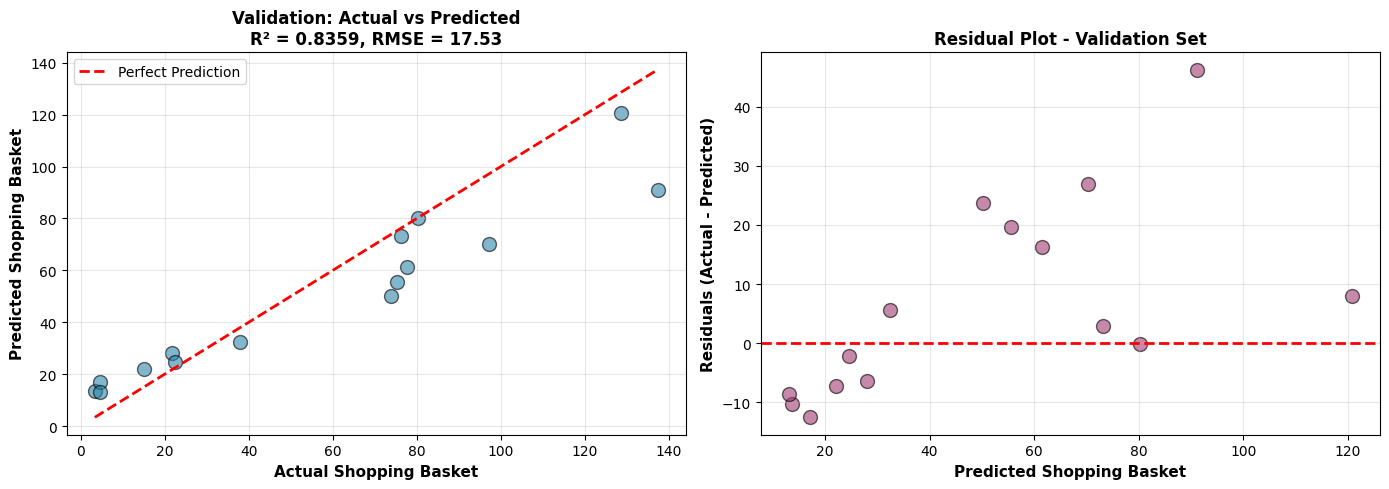


TOP 5 FEATURES QUAN TRỌNG NHẤT (theo abs(coefficient))
                       Feature  Coefficient  Abs_Coefficient
4          Top Fresco Products    12.911577        12.911577
2               Value Products    11.935171        11.935171
3               Brand Products     6.165072         6.165072
6             StoreType_Online     4.347181         4.347181
5  StoreType_Convenient Stores    -3.619124         3.619124


In [61]:
# Visualization kết quả Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted - Validation
ax1 = axes[0]
ax1.scatter(y_val_port, y_val_pred, alpha=0.6, color='#2E86AB', edgecolor='black', s=100)
ax1.plot([y_val_port.min(), y_val_port.max()], [y_val_port.min(), y_val_port.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Shopping Basket', fontweight='bold', fontsize=11)
ax1.set_ylabel('Predicted Shopping Basket', fontweight='bold', fontsize=11)
ax1.set_title(f'Validation: Actual vs Predicted\nR² = {val_r2:.4f}, RMSE = {val_rmse:.2f}', 
              fontweight='bold', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Residuals
ax2 = axes[1]
residuals = y_val_port - y_val_pred
ax2.scatter(y_val_pred, residuals, alpha=0.6, color='#A23B72', edgecolor='black', s=100)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Shopping Basket', fontweight='bold', fontsize=11)
ax2.set_ylabel('Residuals (Actual - Predicted)', fontweight='bold', fontsize=11)
ax2.set_title('Residual Plot - Validation Set', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Hiển thị top features quan trọng nhất
print("\n" + "="*80)
print("TOP 5 FEATURES QUAN TRỌNG NHẤT (theo abs(coefficient))")
print("="*80)
coef_importance = pd.DataFrame({
    'Feature': feature_names_port,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
})
coef_importance = coef_importance.sort_values('Abs_Coefficient', ascending=False)
print(coef_importance.head())

In [62]:
# Tạo nhãn phân loại: Shopping Basket > 50 → class 1, còn lại → class -1 (hoặc 0)
print("="*80)
print("TẠO NHÃN PHÂN LOẠI")
print("="*80)

# Tạo nhãn cho Perceptron (1 và -1)
y_class_perceptron = np.where(y_portfolio > 50, 1, -1)

# Tạo nhãn cho Logistic Regression và Naive Bayes (1 và 0)
y_class_binary = np.where(y_portfolio > 50, 1, 0)

print(f"Tổng số mẫu: {len(y_portfolio)}")
print(f"Số mẫu class 1 (Shopping Basket > 50): {np.sum(y_class_binary == 1)}")
print(f"Số mẫu class 0 (Shopping Basket <= 50): {np.sum(y_class_binary == 0)}")
print(f"Tỷ lệ class 1: {np.sum(y_class_binary == 1)/len(y_class_binary)*100:.2f}%")

# Chia train/validation
y_train_perc = y_class_perceptron[:60]
y_val_perc = y_class_perceptron[60:]

y_train_binary = y_class_binary[:60]
y_val_binary = y_class_binary[60:]

print(f"\n{'='*80}")
print("PHÂN BỐ TRAIN/VALIDATION")
print("="*80)
print(f"Training: Class 1 = {np.sum(y_train_binary == 1)}, Class 0 = {np.sum(y_train_binary == 0)}")
print(f"Validation: Class 1 = {np.sum(y_val_binary == 1)}, Class 0 = {np.sum(y_val_binary == 0)}")

TẠO NHÃN PHÂN LOẠI
Tổng số mẫu: 75
Số mẫu class 1 (Shopping Basket > 50): 43
Số mẫu class 0 (Shopping Basket <= 50): 32
Tỷ lệ class 1: 57.33%

PHÂN BỐ TRAIN/VALIDATION
Training: Class 1 = 35, Class 0 = 25
Validation: Class 1 = 8, Class 0 = 7


In [63]:
# Perceptron cho Portfolio classification
print("="*80)
print("PERCEPTRON - PHÂN LOẠI SHOPPING BASKET")
print("="*80)

# Chuẩn bị dữ liệu với bias
x0_train_port = np.ones((X_train_port_scaled.shape[0], 1))
X_train_port_with_bias = np.concatenate((x0_train_port, X_train_port_scaled), axis=1)

x0_val_port = np.ones((X_val_port_scaled.shape[0], 1))
X_val_port_with_bias = np.concatenate((x0_val_port, X_val_port_scaled), axis=1)

# Transpose cho perceptron
X_train_port_array = X_train_port_with_bias.T
y_train_port_array = y_train_perc.reshape(1, -1)

# Khởi tạo weights
d_port = X_train_port_array.shape[0]
w_init_port = np.random.randn(d_port, 1)

print(f"\nSố features (bao gồm bias): {d_port}")
print(f"Số mẫu training: {X_train_port_array.shape[1]}")

print(f"\nĐang huấn luyện Perceptron...")
start_time_perc_port = time.time()
(w_trained_port, mis_points_port) = perceptron_general(
    X_train_port_array, y_train_port_array, w_init_port, max_iter=1000, verbose=True
)
train_time_perc_port = time.time() - start_time_perc_port

print(f"\n✓ Huấn luyện hoàn tất trong {train_time_perc_port:.4f} giây")

# Test trên validation
X_val_port_array = X_val_port_with_bias.T
y_val_port_array = y_val_perc.reshape(1, -1)
y_pred_perc_port = h(w_trained_port[-1], X_val_port_array)

# Metrics
TP_perc_port = np.sum((y_pred_perc_port == 1) & (y_val_port_array == 1))
TN_perc_port = np.sum((y_pred_perc_port == -1) & (y_val_port_array == -1))
FP_perc_port = np.sum((y_pred_perc_port == 1) & (y_val_port_array == -1))
FN_perc_port = np.sum((y_pred_perc_port == -1) & (y_val_port_array == 1))

acc_perc_port = (TP_perc_port + TN_perc_port) / (TP_perc_port + TN_perc_port + FP_perc_port + FN_perc_port)
prec_perc_port = TP_perc_port / (TP_perc_port + FP_perc_port) if (TP_perc_port + FP_perc_port) > 0 else 0
rec_perc_port = TP_perc_port / (TP_perc_port + FN_perc_port) if (TP_perc_port + FN_perc_port) > 0 else 0

print(f"\n{'='*80}")
print("KẾT QUẢ TRÊN VALIDATION SET")
print("="*80)
print(f"Accuracy:  {acc_perc_port:.4f} ({acc_perc_port*100:.2f}%)")
print(f"Precision: {prec_perc_port:.4f} ({prec_perc_port*100:.2f}%)")
print(f"Recall:    {rec_perc_port:.4f} ({rec_perc_port*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_perc_port}, FP={FP_perc_port}")
print(f"  FN={FN_perc_port}, TP={TP_perc_port}")

print(f"\n{'='*80}")
print("HỆ SỐ MÔ HÌNH PERCEPTRON")
print("="*80)
print(f"Bias (w0): {w_trained_port[-1][0][0]:.4f}")
print(f"\nWeights:")
for i, (name, weight) in enumerate(zip(feature_names_port, w_trained_port[-1][1:, 0])):
    print(f"  {name:<25}: {weight:>8.4f}")

print(f"\n{'='*80}")
print("Ý NGHĨA HỆ SỐ PERCEPTRON")
print("="*80)
print(f"""
- Weight dương: Feature tăng → tăng khả năng Shopping Basket > 50
- Weight âm: Feature tăng → giảm khả năng Shopping Basket > 50
- |Weight| lớn: Feature có ảnh hưởng mạnh đến quyết định phân loại

Top 3 features quan trọng nhất (abs weight):
""")
weight_importance = pd.DataFrame({
    'Feature': feature_names_port,
    'Weight': w_trained_port[-1][1:, 0],
    'Abs_Weight': np.abs(w_trained_port[-1][1:, 0])
})
weight_importance = weight_importance.sort_values('Abs_Weight', ascending=False)
for idx, row in weight_importance.head(3).iterrows():
    print(f"  {row['Feature']:<25}: {row['Weight']:>8.4f} ({'tăng' if row['Weight'] > 0 else 'giảm'} class 1)")

PERCEPTRON - PHÂN LOẠI SHOPPING BASKET

Số features (bao gồm bias): 9
Số mẫu training: 60

Đang huấn luyện Perceptron...
Iteration 50/1000: Accuracy = 0.9500 (95.00%)
Iteration 100/1000: Accuracy = 0.9500 (95.00%)
Iteration 150/1000: Accuracy = 0.9667 (96.67%)
Iteration 200/1000: Accuracy = 0.8833 (88.33%)
Iteration 250/1000: Accuracy = 0.9000 (90.00%)
Iteration 300/1000: Accuracy = 0.9167 (91.67%)
Iteration 350/1000: Accuracy = 0.9000 (90.00%)
Iteration 400/1000: Accuracy = 0.9667 (96.67%)
Iteration 450/1000: Accuracy = 0.9667 (96.67%)
Iteration 500/1000: Accuracy = 0.9667 (96.67%)
Iteration 550/1000: Accuracy = 0.9667 (96.67%)
Iteration 600/1000: Accuracy = 0.9500 (95.00%)
Iteration 650/1000: Accuracy = 0.9333 (93.33%)
Iteration 700/1000: Accuracy = 0.9667 (96.67%)
Iteration 750/1000: Accuracy = 0.9500 (95.00%)
Iteration 800/1000: Accuracy = 0.9667 (96.67%)
Iteration 850/1000: Accuracy = 0.9500 (95.00%)
Iteration 900/1000: Accuracy = 0.9500 (95.00%)
Iteration 950/1000: Accuracy = 0.9

In [64]:
# Logistic Regression cho Portfolio
print("="*80)
print("LOGISTIC REGRESSION - PHÂN LOẠI SHOPPING BASKET")
print("="*80)

lr_port = LogisticRegression(max_iter=1000, random_state=42)

print(f"\nĐang huấn luyện Logistic Regression...")
start_time_lr_port = time.time()
lr_port.fit(X_train_port_scaled, y_train_binary)
train_time_lr_port = time.time() - start_time_lr_port

print(f"✓ Huấn luyện hoàn tất trong {train_time_lr_port:.4f} giây")

# Predict
y_pred_lr_port = lr_port.predict(X_val_port_scaled)

# Metrics
TP_lr_port = np.sum((y_pred_lr_port == 1) & (y_val_binary == 1))
TN_lr_port = np.sum((y_pred_lr_port == 0) & (y_val_binary == 0))
FP_lr_port = np.sum((y_pred_lr_port == 1) & (y_val_binary == 0))
FN_lr_port = np.sum((y_pred_lr_port == 0) & (y_val_binary == 1))

acc_lr_port = (TP_lr_port + TN_lr_port) / (TP_lr_port + TN_lr_port + FP_lr_port + FN_lr_port)
prec_lr_port = TP_lr_port / (TP_lr_port + FP_lr_port) if (TP_lr_port + FP_lr_port) > 0 else 0
rec_lr_port = TP_lr_port / (TP_lr_port + FN_lr_port) if (TP_lr_port + FN_lr_port) > 0 else 0

print(f"\n{'='*80}")
print("KẾT QUẢ TRÊN VALIDATION SET")
print("="*80)
print(f"Accuracy:  {acc_lr_port:.4f} ({acc_lr_port*100:.2f}%)")
print(f"Precision: {prec_lr_port:.4f} ({prec_lr_port*100:.2f}%)")
print(f"Recall:    {rec_lr_port:.4f} ({rec_lr_port*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_lr_port}, FP={FP_lr_port}")
print(f"  FN={FN_lr_port}, TP={TP_lr_port}")

print(f"\n{'='*80}")
print("HỆ SỐ MÔ HÌNH LOGISTIC REGRESSION")
print("="*80)
print(f"Intercept (w0): {lr_port.intercept_[0]:.4f}")
print(f"\nCoefficients:")
for i, (name, coef) in enumerate(zip(feature_names_port, lr_port.coef_[0])):
    print(f"  {name:<25}: {coef:>8.4f}")

print(f"\n{'='*80}")
print("Ý NGHĨA HỆ SỐ LOGISTIC REGRESSION")
print("="*80)
print(f"""
- Coefficient dương: Tăng log-odds của class 1 (Shopping Basket > 50)
- Coefficient âm: Giảm log-odds của class 1
- exp(coefficient) = odds ratio: tỷ lệ thay đổi odds khi feature tăng 1 đơn vị

Top 3 features quan trọng nhất (abs coefficient):
""")
coef_importance_lr = pd.DataFrame({
    'Feature': feature_names_port,
    'Coefficient': lr_port.coef_[0],
    'Abs_Coefficient': np.abs(lr_port.coef_[0]),
    'Odds_Ratio': np.exp(lr_port.coef_[0])
})
coef_importance_lr = coef_importance_lr.sort_values('Abs_Coefficient', ascending=False)
for idx, row in coef_importance_lr.head(3).iterrows():
    print(f"  {row['Feature']:<25}: coef={row['Coefficient']:>7.4f}, OR={row['Odds_Ratio']:>7.4f}")

LOGISTIC REGRESSION - PHÂN LOẠI SHOPPING BASKET

Đang huấn luyện Logistic Regression...
✓ Huấn luyện hoàn tất trong 0.0042 giây

KẾT QUẢ TRÊN VALIDATION SET
Accuracy:  1.0000 (100.00%)
Precision: 1.0000 (100.00%)
Recall:    1.0000 (100.00%)

Confusion Matrix:
  TN=7, FP=0
  FN=0, TP=8

HỆ SỐ MÔ HÌNH LOGISTIC REGRESSION
Intercept (w0): 1.5322

Coefficients:
  Gender                   :   0.3113
  Age                      :   0.3510
  Value Products           :   1.3082
  Brand Products           :   1.6361
  Top Fresco Products      :   0.2414
  StoreType_Convenient Stores:  -0.7786
  StoreType_Online         :   0.7214
  StoreType_Superstore     :   0.0032

Ý NGHĨA HỆ SỐ LOGISTIC REGRESSION

- Coefficient dương: Tăng log-odds của class 1 (Shopping Basket > 50)
- Coefficient âm: Giảm log-odds của class 1
- exp(coefficient) = odds ratio: tỷ lệ thay đổi odds khi feature tăng 1 đơn vị

Top 3 features quan trọng nhất (abs coefficient):

  Brand Products           : coef= 1.6361, OR= 5.1354


In [65]:
# Naive Bayes cho Portfolio
print("="*80)
print("NAIVE BAYES - PHÂN LOẠI SHOPPING BASKET")
print("="*80)

nb_port = GaussianNB()

print(f"\nĐang huấn luyện Naive Bayes...")
start_time_nb_port = time.time()
nb_port.fit(X_train_port_scaled, y_train_binary)
train_time_nb_port = time.time() - start_time_nb_port

print(f"✓ Huấn luyện hoàn tất trong {train_time_nb_port:.4f} giây")

# Predict
y_pred_nb_port = nb_port.predict(X_val_port_scaled)

# Metrics
TP_nb_port = np.sum((y_pred_nb_port == 1) & (y_val_binary == 1))
TN_nb_port = np.sum((y_pred_nb_port == 0) & (y_val_binary == 0))
FP_nb_port = np.sum((y_pred_nb_port == 1) & (y_val_binary == 0))
FN_nb_port = np.sum((y_pred_nb_port == 0) & (y_val_binary == 1))

acc_nb_port = (TP_nb_port + TN_nb_port) / (TP_nb_port + TN_nb_port + FP_nb_port + FN_nb_port)
prec_nb_port = TP_nb_port / (TP_nb_port + FP_nb_port) if (TP_nb_port + FP_nb_port) > 0 else 0
rec_nb_port = TP_nb_port / (TP_nb_port + FN_nb_port) if (TP_nb_port + FN_nb_port) > 0 else 0

print(f"\n{'='*80}")
print("KẾT QUẢ TRÊN VALIDATION SET")
print("="*80)
print(f"Accuracy:  {acc_nb_port:.4f} ({acc_nb_port*100:.2f}%)")
print(f"Precision: {prec_nb_port:.4f} ({prec_nb_port*100:.2f}%)")
print(f"Recall:    {rec_nb_port:.4f} ({rec_nb_port*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(f"  TN={TN_nb_port}, FP={FP_nb_port}")
print(f"  FN={FN_nb_port}, TP={TP_nb_port}")

print(f"\n{'='*80}")
print("THÔNG TIN MÔ HÌNH NAIVE BAYES")
print("="*80)
print(f"Class prior probabilities:")
print(f"  P(class=0): {nb_port.class_prior_[0]:.4f}")
print(f"  P(class=1): {nb_port.class_prior_[1]:.4f}")

print(f"\nMean của từng feature theo class:")
print(f"{'Feature':<25} {'Mean(class=0)':<15} {'Mean(class=1)'}")
print("-" * 60)
for i, name in enumerate(feature_names_port):
    print(f"{name:<25} {nb_port.theta_[0][i]:<15.4f} {nb_port.theta_[1][i]:.4f}")

print(f"\n{'='*80}")
print("Ý NGHĨA MÔ HÌNH NAIVE BAYES")
print("="*80)
print(f"""
Naive Bayes giả định các features độc lập và tuân theo phân phối Gaussian.
Model học được:
1. Prior probability: Xác suất ban đầu của mỗi class
2. Mean & Variance: Giá trị trung bình và phương sai của mỗi feature theo class

Features có mean khác biệt lớn giữa 2 class → quan trọng hơn:
""")

# Tính độ khác biệt mean
mean_diff = pd.DataFrame({
    'Feature': feature_names_port,
    'Mean_Diff': np.abs(nb_port.theta_[1] - nb_port.theta_[0])
})
mean_diff = mean_diff.sort_values('Mean_Diff', ascending=False)
print("\nTop 3 features có mean khác biệt nhất:")
for idx, row in mean_diff.head(3).iterrows():
    print(f"  {row['Feature']:<25}: diff = {row['Mean_Diff']:.4f}")

NAIVE BAYES - PHÂN LOẠI SHOPPING BASKET

Đang huấn luyện Naive Bayes...
✓ Huấn luyện hoàn tất trong 0.0008 giây

KẾT QUẢ TRÊN VALIDATION SET
Accuracy:  0.7333 (73.33%)
Precision: 1.0000 (100.00%)
Recall:    0.5000 (50.00%)

Confusion Matrix:
  TN=7, FP=0
  FN=4, TP=4

THÔNG TIN MÔ HÌNH NAIVE BAYES
Class prior probabilities:
  P(class=0): 0.4167
  P(class=1): 0.5833

Mean của từng feature theo class:
Feature                   Mean(class=0)   Mean(class=1)
------------------------------------------------------------
Gender                    0.0400          -0.0286
Age                       -0.7724         0.5517
Value Products            -0.7860         0.5615
Brand Products            -0.8636         0.6169
Top Fresco Products       -0.6719         0.4799
StoreType_Convenient Stores 0.7159          -0.5114
StoreType_Online          -0.6807         0.4862
StoreType_Superstore      0.0135          -0.0096

Ý NGHĨA MÔ HÌNH NAIVE BAYES

Naive Bayes giả định các features độc lập và tuân the

In [66]:
# So sánh các mô hình
print("="*80)
print("SO SÁNH CÁC MÔ HÌNH PHÂN LOẠI")
print("="*80)

results_portfolio = {
    'Perceptron': {
        'Accuracy': acc_perc_port,
        'Precision': prec_perc_port,
        'Recall': rec_perc_port,
        'Time (s)': train_time_perc_port
    },
    'Logistic Regression': {
        'Accuracy': acc_lr_port,
        'Precision': prec_lr_port,
        'Recall': rec_lr_port,
        'Time (s)': train_time_lr_port
    },
    'Naive Bayes': {
        'Accuracy': acc_nb_port,
        'Precision': prec_nb_port,
        'Recall': rec_nb_port,
        'Time (s)': train_time_nb_port
    }
}

df_portfolio = pd.DataFrame(results_portfolio).T
print("\n", df_portfolio.to_string())

print(f"\n{'='*80}")
print("MÔ HÌNH TỐT NHẤT")
print("="*80)
print(f"Accuracy cao nhất:  {df_portfolio['Accuracy'].idxmax()} ({df_portfolio['Accuracy'].max():.4f})")
print(f"Precision cao nhất: {df_portfolio['Precision'].idxmax()} ({df_portfolio['Precision'].max():.4f})")
print(f"Recall cao nhất:    {df_portfolio['Recall'].idxmax()} ({df_portfolio['Recall'].max():.4f})")
print(f"Nhanh nhất:         {df_portfolio['Time (s)'].idxmin()} ({df_portfolio['Time (s)'].min():.4f}s)")

print(f"\n{'='*80}")
print("GIẢI THÍCH VÀ LÝ DO")
print("="*80)

best_model = df_portfolio['Accuracy'].idxmax()

print(f"""
1. MÔ HÌNH TỐT NHẤT: {best_model}
   - Accuracy: {df_portfolio.loc[best_model, 'Accuracy']:.4f}
   - Precision: {df_portfolio.loc[best_model, 'Precision']:.4f}
   - Recall: {df_portfolio.loc[best_model, 'Recall']:.4f}

2. PHÂN TÍCH TỪNG MÔ HÌNH:

   a) PERCEPTRON:
      - Ưu điểm: Đơn giản, dễ hiểu, phù hợp với dữ liệu linearly separable
      - Nhược điểm: Chỉ tìm được 1 hyperplane, không đảm bảo tối ưu
      - Kết quả: Accuracy = {acc_perc_port:.4f}
      - Phù hợp: Dữ liệu đơn giản, cần model nhanh và dễ giải thích

   b) LOGISTIC REGRESSION:
      - Ưu điểm: Cung cấp xác suất dự đoán, ổn định, có regularization
      - Nhược điểm: Giả định linear boundary
      - Kết quả: Accuracy = {acc_lr_port:.4f}
      - Phù hợp: Cần xác suất dự đoán, dữ liệu có quan hệ tuyến tính

   c) NAIVE BAYES:
      - Ưu điểm: Nhanh nhất, không cần nhiều dữ liệu, xử lý tốt high-dim
      - Nhược điểm: Giả định independence (thực tế features có thể tương quan)
      - Kết quả: Accuracy = {acc_nb_port:.4f}
      - Phù hợp: Ít dữ liệu training, cần tốc độ cao

3. KẾT LUẬN:
   {best_model} cho kết quả tốt nhất vì:
   - Dataset có {X_train_port.shape[0]} mẫu training, {X_train_port.shape[1]} features
   - Dữ liệu đã được chuẩn hóa (StandardScaler)
   - Tỷ lệ class: {np.sum(y_train_binary == 1)}/{np.sum(y_train_binary == 0)} (class 1/class 0)
   
   {'Dataset có thể có quan hệ tuyến tính giữa features và target' if best_model == 'Logistic Regression' 
    else 'Dataset có thể linearly separable' if best_model == 'Perceptron'
    else 'Features có thể độc lập và tuân theo phân phối Gaussian'}

4. KHUYẾN NGHỊ:
   - Production: Sử dụng {best_model}
   - Cần giải thích: Logistic Regression (cung cấp odds ratio)
   - Cần tốc độ: Naive Bayes ({train_time_nb_port:.4f}s)
   - Dataset nhỏ: Naive Bayes (ít data hunger nhất)
""")

SO SÁNH CÁC MÔ HÌNH PHÂN LOẠI

                      Accuracy  Precision  Recall  Time (s)
Perceptron           1.000000        1.0     1.0  0.283104
Logistic Regression  1.000000        1.0     1.0  0.004187
Naive Bayes          0.733333        1.0     0.5  0.000811

MÔ HÌNH TỐT NHẤT
Accuracy cao nhất:  Perceptron (1.0000)
Precision cao nhất: Perceptron (1.0000)
Recall cao nhất:    Perceptron (1.0000)
Nhanh nhất:         Naive Bayes (0.0008s)

GIẢI THÍCH VÀ LÝ DO

1. MÔ HÌNH TỐT NHẤT: Perceptron
   - Accuracy: 1.0000
   - Precision: 1.0000
   - Recall: 1.0000

2. PHÂN TÍCH TỪNG MÔ HÌNH:

   a) PERCEPTRON:
      - Ưu điểm: Đơn giản, dễ hiểu, phù hợp với dữ liệu linearly separable
      - Nhược điểm: Chỉ tìm được 1 hyperplane, không đảm bảo tối ưu
      - Kết quả: Accuracy = 1.0000
      - Phù hợp: Dữ liệu đơn giản, cần model nhanh và dễ giải thích

   b) LOGISTIC REGRESSION:
      - Ưu điểm: Cung cấp xác suất dự đoán, ổn định, có regularization
      - Nhược điểm: Giả định linear bound

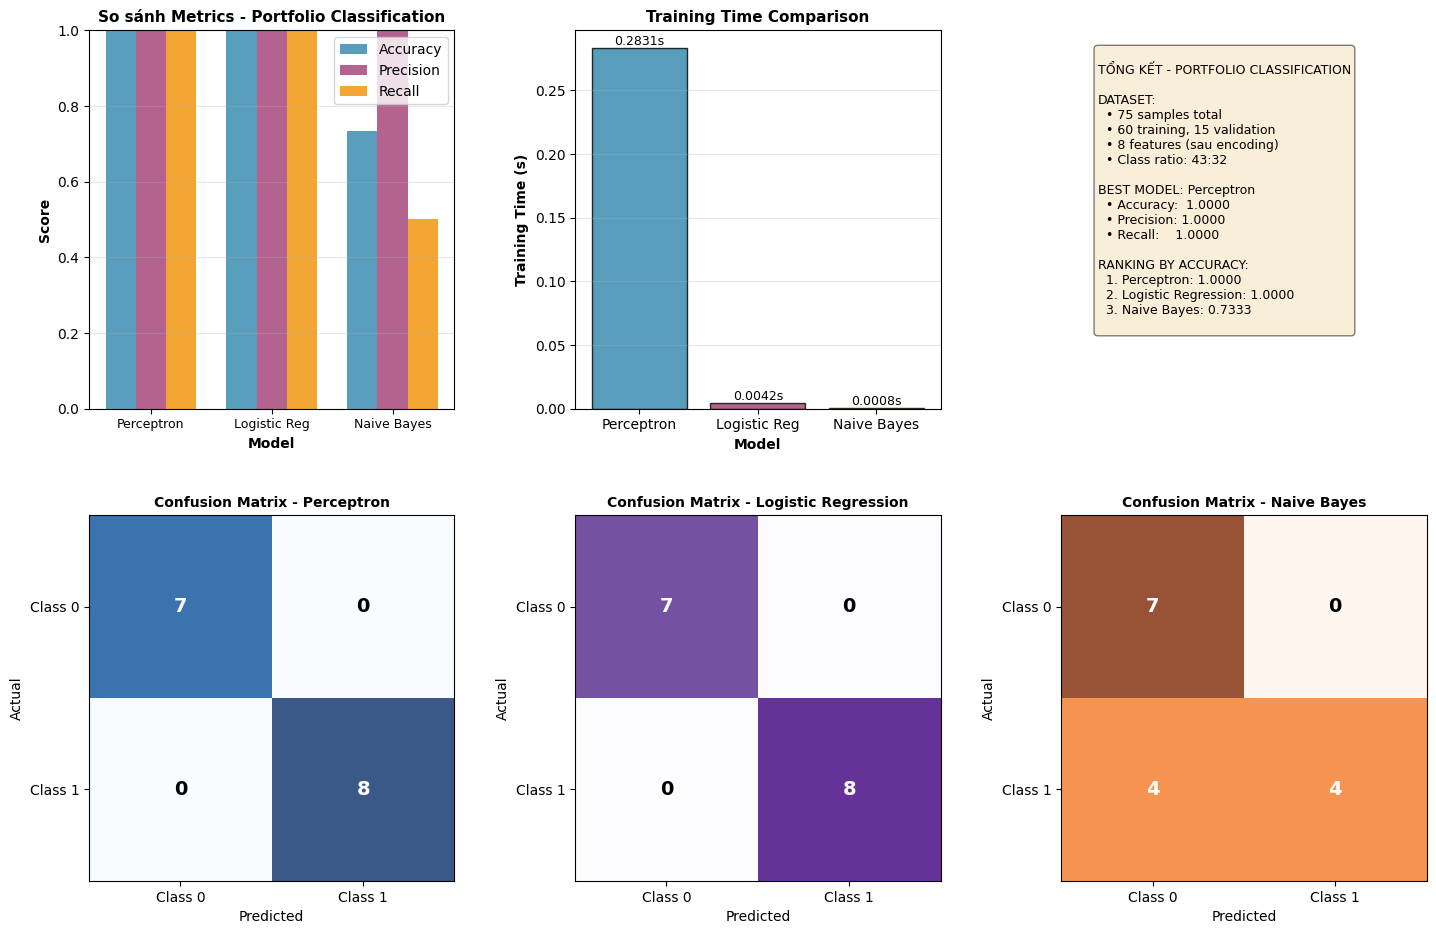

In [68]:
# Visualization so sánh Portfolio
fig = plt.figure(figsize=(15, 10))

# 1. So sánh Metrics
ax1 = plt.subplot(2, 3, 1)
models_port = ['Perceptron', 'Logistic Reg', 'Naive Bayes']
acc_port = [acc_perc_port, acc_lr_port, acc_nb_port]
prec_port = [prec_perc_port, prec_lr_port, prec_nb_port]
rec_port = [rec_perc_port, rec_lr_port, rec_nb_port]

x_port = np.arange(len(models_port))
width_port = 0.25

bars1 = ax1.bar(x_port - width_port, acc_port, width_port, label='Accuracy', alpha=0.8, color='#2E86AB')
bars2 = ax1.bar(x_port, prec_port, width_port, label='Precision', alpha=0.8, color='#A23B72')
bars3 = ax1.bar(x_port + width_port, rec_port, width_port, label='Recall', alpha=0.8, color='#F18F01')

ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('So sánh Metrics - Portfolio Classification', fontweight='bold', fontsize=11)
ax1.set_xticks(x_port)
ax1.set_xticklabels(models_port, fontsize=9)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.0])

# 2. Training Time
ax2 = plt.subplot(2, 3, 2)
times_port = [train_time_perc_port, train_time_lr_port, train_time_nb_port]
colors_time = ['#2E86AB', '#A23B72', '#F18F01']
bars_time = ax2.bar(models_port, times_port, alpha=0.8, color=colors_time, edgecolor='black')

ax2.set_xlabel('Model', fontweight='bold')
ax2.set_ylabel('Training Time (s)', fontweight='bold')
ax2.set_title('Training Time Comparison', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

for bar, t in zip(bars_time, times_port):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{t:.4f}s', ha='center', va='bottom', fontsize=9)

# 3. Confusion Matrix - Perceptron
ax3 = plt.subplot(2, 3, 4)
cm_perc = np.array([[TN_perc_port, FP_perc_port], [FN_perc_port, TP_perc_port]])
im3 = ax3.imshow(cm_perc, cmap='Blues', alpha=0.8)
ax3.set_title('Confusion Matrix - Perceptron', fontweight='bold', fontsize=10)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Class 0', 'Class 1'])
ax3.set_yticklabels(['Class 0', 'Class 1'])

for i in range(2):
    for j in range(2):
        text = ax3.text(j, i, cm_perc[i, j], ha="center", va="center", 
                       color="white" if cm_perc[i, j] > cm_perc.max()/2 else "black",
                       fontsize=14, fontweight='bold')

# 4. Confusion Matrix - Logistic Regression
ax4 = plt.subplot(2, 3, 5)
cm_lr = np.array([[TN_lr_port, FP_lr_port], [FN_lr_port, TP_lr_port]])
im4 = ax4.imshow(cm_lr, cmap='Purples', alpha=0.8)
ax4.set_title('Confusion Matrix - Logistic Regression', fontweight='bold', fontsize=10)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Class 0', 'Class 1'])
ax4.set_yticklabels(['Class 0', 'Class 1'])

for i in range(2):
    for j in range(2):
        text = ax4.text(j, i, cm_lr[i, j], ha="center", va="center",
                       color="white" if cm_lr[i, j] > cm_lr.max()/2 else "black",
                       fontsize=14, fontweight='bold')

# 5. Confusion Matrix - Naive Bayes
ax5 = plt.subplot(2, 3, 6)
cm_nb = np.array([[TN_nb_port, FP_nb_port], [FN_nb_port, TP_nb_port]])
im5 = ax5.imshow(cm_nb, cmap='Oranges', alpha=0.8)
ax5.set_title('Confusion Matrix - Naive Bayes', fontweight='bold', fontsize=10)
ax5.set_xlabel('Predicted')
ax5.set_ylabel('Actual')
ax5.set_xticks([0, 1])
ax5.set_yticks([0, 1])
ax5.set_xticklabels(['Class 0', 'Class 1'])
ax5.set_yticklabels(['Class 0', 'Class 1'])

for i in range(2):
    for j in range(2):
        text = ax5.text(j, i, cm_nb[i, j], ha="center", va="center",
                       color="white" if cm_nb[i, j] > cm_nb.max()/2 else "black",
                       fontsize=14, fontweight='bold')

# 6. Summary
ax6 = plt.subplot(2, 3, 3)
ax6.axis('off')

summary_port = f"""
TỔNG KẾT - PORTFOLIO CLASSIFICATION

DATASET:
  • {len(y_portfolio)} samples total
  • {X_train_port.shape[0]} training, {X_val_port.shape[0]} validation
  • {X_train_port.shape[1]} features (sau encoding)
  • Class ratio: {np.sum(y_class_binary==1)}:{np.sum(y_class_binary==0)}

BEST MODEL: {best_model}
  • Accuracy:  {df_portfolio['Accuracy'].max():.4f}
  • Precision: {df_portfolio.loc[best_model, 'Precision']:.4f}
  • Recall:    {df_portfolio.loc[best_model, 'Recall']:.4f}

RANKING BY ACCURACY:
"""

sorted_models = df_portfolio.sort_values('Accuracy', ascending=False)
for i, (model, row) in enumerate(sorted_models.iterrows(), 1):
    summary_port += f"  {i}. {model}: {row['Accuracy']:.4f}\n"

ax6.text(0.1, 0.95, summary_port, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(pad=3.0)
plt.show()
